# Slotted graphite-plate MSR core — OpenMC CSG model + Latin-hypercube study

**Concept (Brian):** graphite plates with machined slots; plates are stacked with every other plate rotated 90°, so
rows of **vertical fuel slots** alternate with rows of **horizontal coolant slots**. All slots have the **same
machined profile and size**: depth `d`, both side walls **quarter-rounds of radius `d`**, flat bottom `flat_width`
between them → slot width **`w = 2d + flat_width`**. Neighbouring slots in a row are separated by graphite **webs**
(`web_thickness`); each slot row is closed by the solid backing of the next plate — **one shared wall**
(`wall_thickness`) between every fuel row and coolant row.

This notebook:
1. defines the geometry with OpenMC CSG (`build_model(slot_depth, flat_width, web_thickness, wall_thickness, **opts)`),
2. plots it (profile sketch, full-core and close-up xy / xz / yz slices, unit cell; coloured by material),
3. checks the CSG volumes against closed-form area formulas,
4. runs the first model (bare finite cylinder, R = 70 cm, H = 2R, MSRE fuel salt) and a quick unit-cell k-inf,
5. sets up a Latin-hypercube sweep over `slot_depth`, `flat_width`, `web_thickness`, `wall_thickness`
   (`scipy.stats.qmc.LatinHypercube`; enrichment and core radius optional), transport switched by `RUN_TRANSPORT`.

Everything is in this notebook (no helper modules needed). Tested with OpenMC 0.16.0, SciPy 1.18, pandas 3.0.

## Geometry interpretation & assumptions  (edit here first if anything is wrong)

**Axes:** `x` = plate-stacking direction, `y` = horizontal in the plate plane, `z` = vertical.

**Plate stack (confirmed by Brian):** slots are machined into one face of a graphite plate (depth `d`); the rest of the
plate is a solid backing of thickness `wall_thickness`. Plates are stacked along x, alternately rotated 90°, so the
rows alternate fuel / coolant and each row's open mouth is closed by the backing of the next plate. The backing is
therefore **one shared wall** between each fuel row and the adjacent coolant row (`stacking="plates"`, default):

```
 x ──►  |<-- fuel plate -->|<-- coolant plate -->|<-- fuel plate ...
        | F-row  |  wall   | C-row   |  wall     | F-row
        |<- d -->|<t_wall->|<- d --->|<t_wall-->|
   F-row = row of vertical fuel slots      (run along z, width along y, pitch w + t_web in y)
   C-row = row of horizontal coolant slots (run along y, width along z, pitch w + t_web in z)
   unit cell: P_x = 2 (d + t_wall),  P_y = P_z = w + t_web
```

**Shared machined-slot profile** (one function `milled_slot_region()` builds both slot types, just oriented differently):

```
  u (across width) ──►
  0     d            w-d     w
  +=====+=============+=======+   <- mouth: open face (closed by the next plate's backing wall)
   '.   |             |    .'
     '. |    salt     | .'         both side walls: quarter-rounds of radius R = d,
       '+-------------+'           centres on the mouth plane at u = d and u = w-d
        |<- flat_w -->|           <- flat bottom at depth v = d
  v (depth into graphite, +x)          w = 2d + flat_width   (flat_width = 0 -> half-round)
```
* Default `round_location="both_sides"` (full-radius corners on both sides). CSG:
  `slot = [cyl(R=d, centre u=d) ∩ (u ≤ d)] ∪ [rectangle flat_width × d] ∪ [cyl(R=d, centre u=w−d) ∩ (u ≥ w−d)]`, all ∩ (depth ≥ 0);
  cylinder axes = slot run direction. Area `A = flat_width·d + π d²/2`. Graphite = complement of all slots.
* Fuel slot: profile in the **x–y** plane, extruded along **z**. Coolant slot: the same profile in the **x–z** plane, extruded along **y**.
* **All slots identical** (fuel = coolant width, depth, profile) and **one web thickness everywhere**: `web_thickness` is the land
  between neighbouring slots of a row (the only web in the plate stack; rows are separated by the shared wall).
* Optional `coolant_depth=` (default `None` = same as `slot_depth`) gives the coolant slots their own depth (width `2 d_c + flat`); used only in the §9 coolant-only depth scan.
* Every sample is feasible by construction (`d > 0`, `flat_width ≥ 0`, `web > 0`, `wall > 0`).
* Legacy options (not default): `round_location="side"` (one side rounded, w = d + flat), `"bottom"` (U-groove, explicit
  `slot_width ≤ 2d`), `"none"` (square, w = flat); `stacking="interleaved"` (old multi-row slabs with webs between rows).
* **Not modelled:** the run-out radius at the *ends* of a slot; slots are infinite in the unit cell and cut off at the cylinder surface.

**Core and materials:**
* **Default model = bare finite cylindrical core** (`mode="cylinder"`, `reflector_thickness = 0`): a `RectLattice` of the unit-cell
  universe (odd count per axis, a unit cell centred on the axis) truncated by a `ZCylinder` of radius `R = core_radius`
  (default **70 cm**, ~MSRE core radius) and z-planes at ±R (**H = 2R = D**), vacuum boundary. No plenums, vessel, downcomer
  or headers — **the fuel salt outside the core is not modelled**. `mode="unit_cell"` = periodic unit cell → k-infinity (quick mode).
* Materials at 922 K (MSRE operating temperature): **fuel = MSRE 235U-operation fuel salt** 7LiF-BeF₂-ZrF₄-UF₄ 65.0-29.17-5.0-0.83 mol%,
  33.477 wt% U-235 (variable `ENRICHMENT`), 99.995 % Li-7, ρ = 2.575 − 5.13·10⁻⁴·T[°C] g/cc (ORNL sources cited in §2);
  coolant = MSRE coolant salt 7LiF-BeF₂ 66-34 mol%; graphite 1.87 g/cc + `c_Graphite` S(α,β).
  No tube walls/liners — the salt wets the graphite directly.

### Note on wall thickness (rule of thumb — not a qualified design)
* Start at **5 mm** (default `wall_thickness = 0.5` cm); **~3 mm** is a practical floor for machining and handling nuclear graphite.
* **Pressure is not limiting.** Treating the wall over one slot as a plate strip of span `w` and thickness `t` loaded by the
  fuel/coolant pressure difference `p` (< 5 psi ≈ 0.034 MPa): σ ≈ p·w²/(2t²) ≈ **0.4 MPa** for the defaults (w = 2.5 cm, t = 5 mm),
  and only ~6 MPa at the most extreme LHS corner (w = 5.5 cm, t = 3 mm) — compared with ~30–50 MPa flexural strength of nuclear graphite.
* The real limits are **machinability**, **irradiation-induced dimensional change and the resulting internal stress over ~5 years**,
  **salt permeation / fuel–coolant cross-leak** through a thin wall, and component tolerances. The wall's **thermal
  resistance is minor** compared with the salt-side film resistances.

In [1]:
# ---- user switches -----------------------------------------------------------------------------------
import os, math, json, shutil, warnings, re, time, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import openmc
from scipy.stats import qmc

WORK_DIR = os.path.abspath(os.environ.get("MSR_WORK_DIR", "."))      # PNGs / CSV / run dirs go here
RUN_KINF       = True      # quick unit-cell k-infinity run of the default geometry (~1 min)
RUN_BASELINE   = True      # finite-cylinder k-eff run of the default geometry (the "first model")
RUN_TRANSPORT  = False     # transport for every LHS sample (set True for the sweep; skipped without nuclear data)
PARTICLES, BATCHES, INACTIVE = 10000, 100, 40   # finite core: 600k active histories -> k std ~100 pcm
# all transport steps are skipped automatically if no cross_sections.xml is found

# ---- core --------------------------------------------------------------------------------------------------
MODE = "cylinder"          # "cylinder" (finite core, H = 2R, vacuum boundary) or "unit_cell" (periodic, k-inf)
CORE_RADIUS = 70.0         # cm; H = 2R = 140 cm.  (MSRE graphite core radius was 70.2 cm - IRPhEP benchmark)
REFLECTOR_THICKNESS = 0.0  # cm of graphite around the cylinder (side, top, bottom); 0 = bare core
THREADS = None             # None = all OpenMP threads

# ---- default geometry (cm) --------------------------------------------------------------------------------
DEFAULTS = dict(slot_depth=1.0, flat_width=0.5, web_thickness=1.5, wall_thickness=0.5)   # -> slot width w = 2.5 cm
GEOM_OPTS = dict(round_location="both_sides", stacking="plates")                          # Brian's design (defaults)

# ---- fuel ------------------------------------------------------------------------------------------------
ENRICHMENT = 33.477        # U-235 WEIGHT % of total uranium. Default = MSRE 235U operation (ORNL-4658 Table 2.8)
TEMPERATURE_K = 922.0      # material temperature (MSRE operating ~650 C); salt densities follow ORNL correlations

import sys
if shutil.which("openmc") is None:                 # make the conda env's `openmc` executable visible to model.run()
    os.environ["PATH"] = os.path.join(sys.prefix, "bin") + os.pathsep + os.environ.get("PATH", "")
USE_NUCLEAR_DATA = os.environ.get("MSR_USE_XS", "1") == "1"   # set False to force the no-data path

# nuclear data: $OPENMC_CROSS_SECTIONS or first existing candidate below
for _xs in ([] if not USE_NUCLEAR_DATA else [os.environ.get("OPENMC_CROSS_SECTIONS"),
            os.path.expanduser("~/nucdata/endfb-viii.0-hdf5/cross_sections.xml"),
            "/workspace/nucdata/endfb-viii.0-hdf5/cross_sections.xml"]):
    if _xs and os.path.exists(_xs):
        openmc.config["cross_sections"] = _xs
        break
if not USE_NUCLEAR_DATA:
    openmc.config.pop("cross_sections", None)
HAVE_XS = openmc.config.get("cross_sections") is not None and os.path.exists(str(openmc.config.get("cross_sections")))
print("OpenMC", openmc.__version__, "| cross sections:", openmc.config.get("cross_sections") if HAVE_XS else "NOT FOUND (transport skipped, python plot fallback)")
print("WORK_DIR =", WORK_DIR)

OpenMC 0.16.0 | cross sections: /workspace/nucdata/endfb-viii.0-hdf5/cross_sections.xml
WORK_DIR = /workspace/msr_slab


## 1. Shared machined-slot profile (fuel **and** coolant): double-rounded slot, w = 2d + flat

In [2]:
# 1. Shared machined-slot profile (used for BOTH fuel and coolant slots)
#   local 2-D coords of the slot cross-section:
#     u = across the slot width (0 .. w),  v = depth measured from the mouth (0 .. d)
#   round_location:
#     "both_sides" : (DEFAULT) both lateral side walls are quarter-rounds of radius R = d, centred on
#                    the MOUTH plane at u = d and u = w-d, with a flat bottom of width `flat` between
#                    them  ->  w = 2d + flat  (flat >= 0; flat = 0 gives a half-round).
#     "side"       : (legacy) only one side wall is a quarter-round R = d  ->  w = d + flat.
#     "bottom"     : (legacy) flat parallel sides, arc bottom R = d centred at mid-width on the mouth
#                    plane (U-groove); needs an explicit slot_width <= 2d.
#     "none"       : (legacy) plain rectangle, w = flat.
#   round_side ("side" only): "+" -> rounded wall at the high-u side, "-" -> low-u side.
PROFILES = ("both_sides", "side", "bottom", "none")

def slot_width_from(d, flat, round_location="both_sides"):
    """Total slot width at the mouth from depth and flat-bottom width."""
    if round_location == "both_sides":
        return 2.0 * d + flat
    if round_location == "side":
        return d + flat
    if round_location == "none":
        return flat
    raise ValueError("round_location='bottom' has no flat bottom: give slot_width explicitly")

def profile_area(w, d, round_location="both_sides"):
    if round_location == "both_sides":
        return (w - 2 * d) * d + math.pi * d**2 / 2.0
    if round_location == "side":
        return (w - d) * d + math.pi * d**2 / 4.0
    if round_location == "bottom":
        a = w / 2.0
        return a * math.sqrt(d**2 - a**2) + d**2 * math.asin(a / d)
    if round_location == "none":
        return w * d
    raise ValueError(round_location)

def profile_perimeter(w, d, round_location="both_sides"):
    """Full wetted perimeter (mouth included: the mouth is closed by graphite too)."""
    if round_location == "both_sides":
        return w + (w - 2 * d) + math.pi * d
    if round_location == "side":
        return w + (w - d) + d + math.pi * d / 2.0
    if round_location == "bottom":
        a = w / 2.0
        return w + 2.0 * math.sqrt(d**2 - a**2) + 2.0 * d * math.asin(a / d)
    if round_location == "none":
        return 2.0 * (w + d)
    raise ValueError(round_location)

def profile_feasible(w, d, round_location="both_sides"):
    tol = 1e-9
    if round_location not in PROFILES:
        return False, f"round_location must be one of {PROFILES}"
    if w <= 0 or d <= 0:
        return False, "slot width and slot_depth must be > 0"
    if round_location == "both_sides" and w < 2 * d - tol:
        return False, f"round_location='both_sides' needs slot_width >= 2*slot_depth (w={w:.3g} < 2d={2*d:.3g})"
    if round_location == "side" and w < d - tol:
        return False, f"round_location='side' needs slot_width >= slot_depth (w={w:.3g} < d={d:.3g})"
    if round_location == "bottom" and w > 2 * d + tol:
        return False, f"round_location='bottom' needs slot_width <= 2*slot_depth (w={w:.3g} > 2d={2*d:.3g})"
    return True, ""

def profile_outline(w, d, round_location="both_sides", round_side="+", n=60):
    """Closed (u, v) polyline of the profile - for sketches only."""
    if round_location == "none":
        pts = [(0, 0), (w, 0), (w, d), (0, d)]
    elif round_location == "both_sides":
        th = np.linspace(0, np.pi / 2, n)
        right = [(w - d + d * np.cos(t), d * np.sin(t)) for t in th]          # (w,0) -> (w-d,d)
        left = [(d - d * np.sin(t), d * np.cos(t)) for t in th]               # (d,d) -> (0,0)
        pts = [(0, 0)] + right + left
    elif round_location == "side":
        th = np.linspace(0, np.pi / 2, n)
        arc = [(w - d + d * np.cos(t), d * np.sin(t)) for t in th]            # (w,0) -> (w-d,d)
        pts = [(0, 0)] + arc + [(0, d)]
    else:  # bottom
        a = w / 2; h = math.sqrt(d**2 - a**2); t0 = math.asin(a / d)
        th = np.linspace(-t0, t0, n)
        arc = [(a + d * np.sin(t), d * np.cos(t)) for t in th]
        pts = [(0, 0)] + [(0, h)] + arc + [(w, h), (w, 0)]
    pts = np.array(pts, float)
    if round_side == "-" and round_location == "side":
        pts[:, 0] = w - pts[:, 0]
    return np.vstack([pts, pts[:1]])

_PLANE = {"x": openmc.XPlane, "y": openmc.YPlane, "z": openmc.ZPlane}

def _cylinder(axis, depth_axis, width_axis, c_depth, c_width, r):
    """Cylinder whose axis is the slot's run direction."""
    kw = {f"{depth_axis}0": c_depth, f"{width_axis}0": c_width, "r": r}
    return {"x": openmc.XCylinder, "y": openmc.YCylinder, "z": openmc.ZCylinder}[axis](**kw)

def milled_slot_region(run_axis, depth_axis, width_axis, mouth, u0, w, d,
                       round_location="both_sides", round_side="+", depth_sign=+1):
    """CSG region of ONE machined slot (infinite along run_axis).

    mouth      : coordinate of the open face along depth_axis
    depth_sign : +1 -> slot goes from `mouth` towards +depth_axis
    u0, w      : slot occupies width_axis in [u0, u0+w] at the mouth
    """
    ok, msg = profile_feasible(w, d, round_location)
    if not ok:
        raise ValueError(msg)
    P_d, P_w = _PLANE[depth_axis], _PLANE[width_axis]
    m = P_d(mouth)
    b = P_d(mouth + depth_sign * d)
    in_depth = (+m & -b) if depth_sign > 0 else (-m & +b)
    beyond_mouth = +m if depth_sign > 0 else -m        # half-space on the graphite side of the mouth
    lo, hi = u0, u0 + w
    cyl = lambda uc: _cylinder(run_axis, depth_axis, width_axis, mouth, uc, d)
    if round_location == "none":
        return in_depth & +P_w(lo) & -P_w(hi)
    if round_location == "both_sides":
        # [left quarter-disc] U [flat-bottom rectangle] U [right quarter-disc]; arc centres on the mouth plane
        pl, pr = P_w(lo + d), P_w(hi - d)
        left = -cyl(lo + d) & beyond_mouth & -pl
        right = -cyl(hi - d) & beyond_mouth & +pr
        if w - 2 * d > 1e-9:
            return left | (in_depth & +pl & -pr) | right
        return left | right                          # flat = 0: half-round
    if round_location == "side":
        if round_side == "+":
            uc = hi - d                     # arc centre (on mouth plane)
            rect = in_depth & +P_w(lo) & -P_w(uc)
            quarter = -cyl(uc) & beyond_mouth & +P_w(uc)
        else:
            uc = lo + d
            rect = in_depth & +P_w(uc) & -P_w(hi)
            quarter = -cyl(uc) & beyond_mouth & -P_w(uc)
        return rect | quarter
    if round_location == "bottom":
        uc = 0.5 * (lo + hi)
        return beyond_mouth & +P_w(lo) & -P_w(hi) & -cyl(uc)
    raise ValueError(round_location)

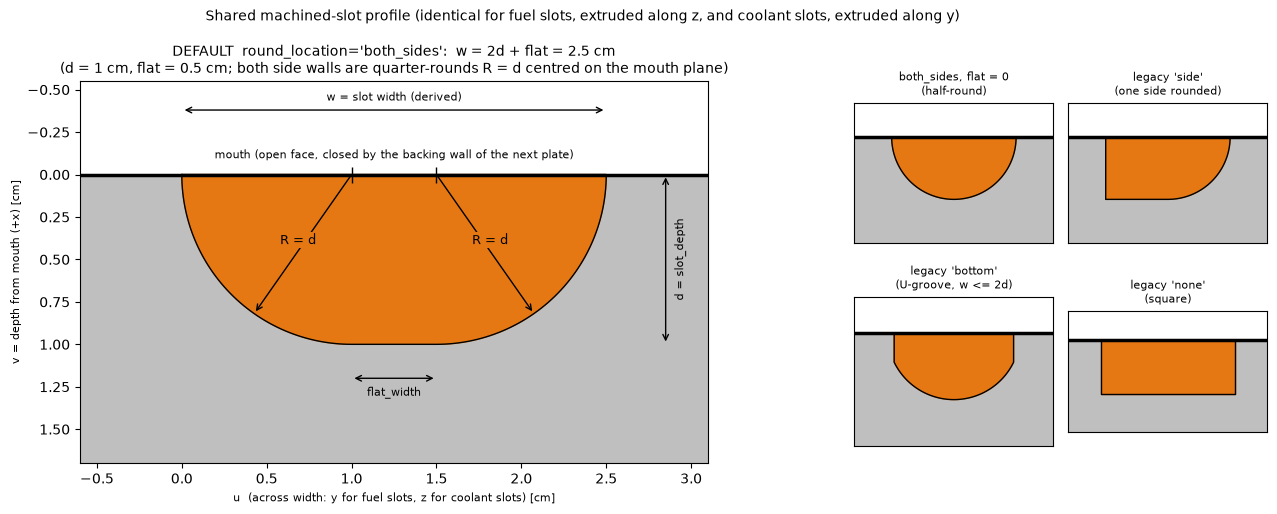

In [3]:
def sketch_profiles(d=1.0, flat=0.5, filename=None):
    """Annotated cross-sections of the shared machined-slot profile: the default double-rounded slot
    (large panel) and the legacy options (small panels)."""
    w = 2 * d + flat
    fig = plt.figure(figsize=(14, 5.2))
    gs = fig.add_gridspec(2, 4, width_ratios=[2.2, 2.2, 1, 1], height_ratios=[1, 1])
    ax0 = fig.add_subplot(gs[:, :2])
    small = [fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[0, 3]), fig.add_subplot(gs[1, 2]), fig.add_subplot(gs[1, 3])]

    def draw(ax, loc, ww, title, big=False):
        ax.add_patch(plt.Rectangle((-0.6, 0), ww + 1.2, d + 0.7, color="0.75", zorder=0))
        o = profile_outline(ww, d, loc)
        ax.fill(o[:, 0], o[:, 1], color="#e67814", zorder=1)
        ax.plot(o[:, 0], o[:, 1], "k", lw=1)
        ax.axhline(0, color="k", lw=2.5)
        ax.set_xlim(-0.6, ww + 0.6); ax.set_ylim(d + 0.7, -0.55); ax.set_aspect("equal")
        ax.set_title(title, fontsize=10 if big else 8)
        if not big:
            ax.set_xticks([]); ax.set_yticks([])

    draw(ax0, "both_sides", w, f"DEFAULT  round_location='both_sides':  w = 2d + flat = {w:g} cm\n"
         f"(d = {d:g} cm, flat = {flat:g} cm; both side walls are quarter-rounds R = d centred on the mouth plane)", big=True)
    for uc, ang in [(d, 125), (w - d, 55)]:
        ax0.plot([uc], [0], "k+", ms=12)
        a = np.deg2rad(ang)
        ax0.annotate("", xy=(uc + d * np.cos(a), d * np.sin(a)), xytext=(uc, 0), arrowprops=dict(arrowstyle="->"))
        ax0.text(uc + 0.55 * d * np.cos(a), 0.5 * d * np.sin(a), "R = d", fontsize=9, ha="center",
                 bbox=dict(fc="#e67814", ec="none", pad=0.5))
    ax0.text(w / 2, -0.08, "mouth (open face, closed by the backing wall of the next plate)", ha="center", va="bottom", fontsize=8)
    ax0.annotate("", xy=(0, -0.38), xytext=(w, -0.38), arrowprops=dict(arrowstyle="<->"))
    ax0.text(w / 2, -0.42, "w = slot width (derived)", ha="center", va="bottom", fontsize=8)
    if flat > 0:
        ax0.annotate("", xy=(d, d + 0.2), xytext=(w - d, d + 0.2), arrowprops=dict(arrowstyle="<->"))
        ax0.text(w / 2, d + 0.25, "flat_width", ha="center", va="top", fontsize=8)
    ax0.annotate("", xy=(w + 0.35, 0), xytext=(w + 0.35, d), arrowprops=dict(arrowstyle="<->"))
    ax0.text(w + 0.4, d / 2, "d = slot_depth", rotation=90, va="center", fontsize=8)
    ax0.set_xlabel("u  (across width: y for fuel slots, z for coolant slots) [cm]", fontsize=8)
    ax0.set_ylabel("v = depth from mouth (+x) [cm]", fontsize=8)

    draw(small[0], "both_sides", 2 * d, "both_sides, flat = 0\n(half-round)")
    draw(small[1], "side", d + flat + d / 2, "legacy 'side'\n(one side rounded)")
    draw(small[2], "bottom", 2 * d * 0.9, "legacy 'bottom'\n(U-groove, w <= 2d)")
    draw(small[3], "none", w, "legacy 'none'\n(square)")
    fig.suptitle("Shared machined-slot profile (identical for fuel slots, extruded along z, and coolant slots, extruded along y)",
                 fontsize=10)
    fig.tight_layout()
    if filename:
        fig.savefig(filename, dpi=150)
    return fig

fig = sketch_profiles(d=DEFAULTS["slot_depth"], flat=DEFAULTS["flat_width"], filename=os.path.join(WORK_DIR, "profile_sketch.png"))
plt.show()

## 2. Materials — default fuel = MSRE fuel salt (U-235 operation), per ORNL sources

| Quantity | Value used (default) | Source |
|---|---|---|
| Fuel salt composition | 7LiF-BeF₂-ZrF₄-UF₄ **65.0-29.17-5.0-0.83 mol%** | R. E. Thoma, *Chemical Aspects of MSRE Operations*, ORNL-4658 (1971), p. 10–11 (fuel for 235U operation; also Table 1.1: 65-29.2-5-0.83) |
| Uranium isotopics (start of power operation, run 4-1) | U-234 0.342, **U-235 33.477**, U-236 0.141, U-238 66.041 wt% | ORNL-4658 Table 2.8 |
| Li-7 in fuel carrier salt | **99.995 at%** (batch assays 99.994–99.996) | ORNL-4658 Table 2.11; same value used in the IRPhEP MSRE benchmark (Shen/Fratoni et al., PHYSOR 2020) |
| Fuel density | **ρ = 2.575 − 5.13×10⁻⁴·T(°C) g/cm³** (±1 %) → 2.242 g/cm³ at 649 °C (139.9 lb/ft³ at 650 °C) | ORNL-4658 Table 8.2 (Cantor molar-volume method; Table 8.3) |
| Coolant salt | 7LiF-BeF₂ 66-34 mol%, 99.992 % Li-7, ρ = 2.214 − 4.2×10⁻⁴·T(°C) → 1.941 g/cm³ at 649 °C | ORNL-4658 Tables 2.1, 8.1; ORNL-4616 |
| Graphite | 1.87 g/cm³ (MSRE grade CGB), pure C + `c_Graphite` | IRPhEP MSRE benchmark evaluation (1.87 ± 0.02 g/cm³) |

**Enrichment variable:** `ENRICHMENT` (top cell) = U-235 **weight %** of total uranium; also `build_model(..., enrichment=...)`,
`make_materials(enrichment=...)` and an optional 5th LHS dimension (`LHS_BOUNDS["enrichment"]`, off by default).
U-234/U-236 scale proportionally with enrichment (`minor_u="scale"`; exact MSRE isotopics at 33.477 wt%);
use `fuel={"minor_u": "none"}` for a pure U-235/U-238 vector.
The UF₄ mole fraction stays at 0.83 mol% when enrichment changes (so changing enrichment changes the U-235 loading).

**Alternatives found in ORNL sources (not used by default; switch via the `fuel=` dict):**
* Nominal design composition 65-29.1-5-0.9 mol% (ORNL-TM-728, Robertson 1965, Table 2.1; ORNL-4616; Haubenreich & Engel, *Nucl. Appl. Tech.* 8 (1970)); U "about 32 %" (ORNL-4616) / "33 %" (Haubenreich & Engel) enriched.
* Zero-power first-criticality salt 64.88-29.27-5.06-0.79 mol%, 1.408 wt% U-235 in salt, ρ = 2.3275 ± 0.016 g/cm³ at 638 °C (IRPhEP MSRE benchmark).
* Density: in-reactor inventory estimate 139.01 lb/ft³ (2.227 g/cm³) at start of power operation; electrical-probe correlation ρ = 2.848 − 7.69×10⁻⁴·T(°C) (2.35 g/cm³ at 650 °C); design value 141 lb/ft³ (2.26 g/cm³) (ORNL-4658 §8.2, Table 8.3).
* Li-7: "at least 99.99 %" (ORNL-4616), 99.994 % (ORNL-TM-728 Table 2.1).

In [4]:
# 2. Materials (MSRE fuel salt per ORNL sources - see the markdown cell above)
import re
def _formula(compound):
    return {el: int(n) if n else 1 for el, n in re.findall(r"([A-Z][a-z]?)(\d*)", compound)}

MSRE_U235_WT_PCT = 33.477      # U-235 wt% of total U at start of 235U power operation (ORNL-4658 Table 2.8, run 4-1)

DEFAULT_FUEL = dict(           # MSRE fuel salt, 235U operation (ORNL-4658, R.E. Thoma 1971)
    name="fuel salt (MSRE 7LiF-BeF2-ZrF4-UF4 65.0-29.17-5.0-0.83)",
    composition_mol={"LiF": 65.0, "BeF2": 29.17, "ZrF4": 5.0, "UF4": 0.83},   # mol%  (ORNL-4658 p.10)
    density_a=2.575, density_b=5.13e-4,   # rho[g/cc] = a - b*T[degC]  (ORNL-4658 Table 8.2) -> 2.242 at 649 C
    density=None,                         # set a number (g/cc) to override the correlation
    u235_wt_pct=MSRE_U235_WT_PCT,         # ENRICHMENT = U-235 WEIGHT % of total uranium
    u234_wt_pct=0.342, u236_wt_pct=0.141, # ORNL-4658 Table 2.8 (run 4-1 nominal); U-238 = balance (66.041)
    minor_u="scale",                      # 'scale': U-234/U-236 scale with enrichment (exact MSRE values at 33.477)
                                          # 'fixed': use the wt% above as given;  'none': U-235 + U-238 only
    li7_at_pct=99.995,                    # 7Li assay of MSRE fuel carrier salt (ORNL-4658 Table 2.11: 99.994-99.996)
)
DEFAULT_COOLANT = dict(        # MSRE coolant/flush salt  7LiF-BeF2 66-34 mol%
    name="coolant salt (MSRE 7LiF-BeF2 66-34)",
    composition_mol={"LiF": 66.0, "BeF2": 34.0},
    density_a=2.214, density_b=4.2e-4,    # ORNL-4658 Table 8.1 (Li2BeF4) -> 1.941 g/cc at 649 C
    density=None,
    li7_at_pct=99.992,                    # ORNL-4658 Table 2.1 (coolant/flush batches 99.991-99.992)
)
DEFAULT_GRAPHITE = dict(name="graphite (MSRE CGB, 1.87 g/cc)", density=1.87, sab="c_Graphite")
# 1.87 +/- 0.02 g/cc: MSRE grade-CGB graphite density used in the IRPhEP MSRE benchmark evaluation (Fratoni et al.).
# Pure carbon (no boron impurity) - placeholder for Brian's actual graphite grade.

def salt_density(spec, temperature_K):
    if spec.get("density") is not None:
        return float(spec["density"])
    return spec["density_a"] - spec["density_b"] * (temperature_K - 273.15)

def uranium_wt_fractions(u235_wt_pct, u234_wt_pct=0.0, u236_wt_pct=0.0, minor_u="scale"):
    """Return {nuclide: wt fraction of U}.  `u235_wt_pct` = enrichment in WEIGHT percent."""
    e = float(u235_wt_pct)
    if not 0.0 < e <= 100.0:
        raise ValueError(f"enrichment (U-235 wt%) must be in (0, 100], got {e}")
    if minor_u == "scale":
        w234, w236 = u234_wt_pct * e / MSRE_U235_WT_PCT, u236_wt_pct * e / MSRE_U235_WT_PCT
    elif minor_u == "fixed":
        w234, w236 = u234_wt_pct, u236_wt_pct
    elif minor_u == "none":
        w234 = w236 = 0.0
    else:
        raise ValueError("minor_u must be 'scale', 'fixed' or 'none'")
    w238 = 100.0 - e - w234 - w236
    if w238 < -1e-9:
        raise ValueError(f"U-234 + U-235 + U-236 exceed 100 wt% (enrichment {e}); use minor_u='none'")
    w = {"U234": w234, "U235": e, "U236": w236, "U238": max(w238, 0.0)}
    return {k: v / 100.0 for k, v in w.items() if v > 0}

_AMU = {"U234": 234.0409521, "U235": 235.0439299, "U236": 236.0455680, "U238": 238.0507882}

def make_salt(spec, temperature=922.0):
    """openmc.Material from mol% of compounds, isotopics and a density correlation."""
    atoms = {}
    tot = sum(spec["composition_mol"].values())
    for comp, x in spec["composition_mol"].items():
        for el, n in _formula(comp).items():
            atoms[el] = atoms.get(el, 0.0) + n * x / tot
    mat = openmc.Material(name=spec["name"], temperature=temperature)
    for el, a in atoms.items():
        if el == "Li":
            f7 = spec.get("li7_at_pct", 99.995) / 100.0
            mat.add_nuclide("Li7", a * f7); mat.add_nuclide("Li6", a * (1 - f7))
        elif el == "U":
            wf = uranium_wt_fractions(spec["u235_wt_pct"], spec.get("u234_wt_pct", 0.0),
                                      spec.get("u236_wt_pct", 0.0), spec.get("minor_u", "scale"))
            moles = {k: v / _AMU[k] for k, v in wf.items()}                 # wt -> atom fractions
            s = sum(moles.values())
            for k, m in moles.items():
                mat.add_nuclide(k, a * m / s)
        elif el in ("Be", "F", "Na"):                                     # mono-isotopic
            mat.add_nuclide({"Be": "Be9", "F": "F19", "Na": "Na23"}[el], a)
        else:
            mat.add_element(el, a)
    mat.set_density("g/cm3", salt_density(spec, temperature))
    return mat

def make_materials(fuel=None, coolant=None, graphite=None, temperature=922.0, enrichment=None):
    """enrichment: U-235 wt% of uranium (None -> MSRE value, 33.477 wt%)."""
    fuel = {**DEFAULT_FUEL, **(fuel or {})}
    if enrichment is not None:
        fuel["u235_wt_pct"] = float(enrichment)
    coolant = {**DEFAULT_COOLANT, **(coolant or {})}
    graphite = {**DEFAULT_GRAPHITE, **(graphite or {})}
    m_fuel = make_salt(fuel, temperature); m_fuel.depletable = True
    m_cool = make_salt(coolant, temperature)
    m_gr = openmc.Material(name=graphite["name"], temperature=temperature)
    m_gr.add_element("C", 1.0)
    m_gr.set_density("g/cm3", graphite["density"])
    if graphite.get("sab"):
        m_gr.add_s_alpha_beta(graphite["sab"])
    return {"fuel": m_fuel, "coolant": m_cool, "graphite": m_gr}

_m = make_materials(temperature=TEMPERATURE_K, enrichment=ENRICHMENT)
for k, m in _m.items():
    print(f"{k:9s} {m.name:55s} {m.density:.4f} g/cc @ {m.temperature:.0f} K  nuclides: {', '.join(n.name for n in m.nuclides)}")
print("uranium vector (wt% of U):", {k: round(100 * v, 3) for k, v in uranium_wt_fractions(
      ENRICHMENT, DEFAULT_FUEL["u234_wt_pct"], DEFAULT_FUEL["u236_wt_pct"], DEFAULT_FUEL["minor_u"]).items()})
print(f"U-235 mass fraction in fuel salt: {100 * _m['fuel'].get_mass_density('U235') / _m['fuel'].density:.3f} wt%")

fuel      fuel salt (MSRE 7LiF-BeF2-ZrF4-UF4 65.0-29.17-5.0-0.83) 2.2421 g/cc @ 922 K  nuclides: Li7, Li6, F19, Be9, Zr90, Zr91, Zr92, Zr94, Zr96, U234, U235, U236, U238
coolant   coolant salt (MSRE 7LiF-BeF2 66-34)                     1.9415 g/cc @ 922 K  nuclides: Li7, Li6, F19, Be9
graphite  graphite (MSRE CGB, 1.87 g/cc)                          1.8700 g/cc @ 922 K  nuclides: C12, C13
uranium vector (wt% of U): {'U234': 0.342, 'U235': 33.477, 'U236': 0.141, 'U238': 66.04}
U-235 mass fraction in fuel salt: 1.584 wt%


## 3. Parameter validation, layer stack and analytic volume fractions
`resolve_params()` validates the inputs (positive d/web/wall, flat_width ≥ 0), derives `slot_width = 2d + flat_width` and returns the x-layer stack;
`analytic_metrics()` gives exact volume fractions / moderator-to-fuel ratio for the periodic cell (no transport needed).

In [5]:
# 3. Layer stack / unit-cell dimensions (pure python - no OpenMC objects)
STACKINGS = ("plates", "interleaved")

def resolve_params(slot_depth=1.0, flat_width=0.5, web_thickness=1.5, wall_thickness=0.5, *,
                   round_location="both_sides", slot_width=None, stacking="plates", n_slot_pairs=2,
                   round_side="+", coolant_depth=None, **_ignored):
    """Validate the parameters and return the unit-cell layout.

    Primary parameters: slot_depth d, flat_width (flat bottom between the two radii), web_thickness,
    wall_thickness.  Derived: slot_width w = 2d + flat (round_location='both_sides').  All slots
    (fuel and coolant) have the same size and profile; ONE web thickness is used everywhere.

    stacking="plates" (default, Brian's design): each graphite plate has one row of slots machined into
        one face (depth d) and a solid backing (wall_thickness).  Plates are stacked along x, every other
        plate rotated 90 deg, so fuel rows (slots along z) and coolant rows (slots along y) alternate and
        each row is closed by the backing of the next plate -> ONE shared wall between every fuel row and
        coolant row.  Layers along x: F | wall | C | wall.  The web is the land between neighbouring slots
        of a row (in-row).
    stacking="interleaved" (legacy): a slab holds n_slot_pairs x (F, web, C) rows separated by webs,
        slabs separated by one wall: F web C [web F web C]*(n-1) wall.

    coolant_depth (optional, default None = slot_depth): separate depth d_c for the coolant slots, same profile
        rule and same flat_width -> coolant width w_c = 2 d_c + flat.  The unit cell stays consistent because
        fuel slots repeat along y (P_y = w + web) and coolant slots along z (P_z = w_c + web), and the
        coolant layer is d_c thick (P_x = d + d_c + 2 wall for plates).  With coolant_depth=None everything
        is identical to the uniform-slot design.

    `layers` entries are (kind, thickness), kind in {'F','C','web','wall'}; F layers are d, C layers d_c thick.
    """
    d, t_web, t_wall = map(float, (slot_depth, web_thickness, wall_thickness))
    dc = d if coolant_depth is None else float(coolant_depth)
    errs = []
    for k, v in dict(slot_depth=d, coolant_depth=dc, web_thickness=t_web, wall_thickness=t_wall).items():
        if not (v > 0 and math.isfinite(v)):
            errs.append(f"{k} must be a positive finite number (got {v})")
    if round_location not in PROFILES:
        errs.append(f"round_location must be one of {PROFILES}")
    if stacking not in STACKINGS:
        errs.append(f"stacking must be one of {STACKINGS}")
    if stacking == "interleaved" and (int(n_slot_pairs) != n_slot_pairs or n_slot_pairs < 1):
        errs.append("n_slot_pairs must be an integer >= 1")
    if round_side not in ("+", "-"):
        errs.append("round_side must be '+' or '-'")
    w = wc = None
    if not errs:
        if slot_width is not None:
            w = wc = float(slot_width)          # legacy: explicit width used for both slot types
        elif round_location == "bottom":
            errs.append("round_location='bottom' needs an explicit slot_width")
        else:
            f = float(flat_width)
            if not (f >= 0 and math.isfinite(f)):
                errs.append(f"flat_width must be >= 0 (got {flat_width})")
            else:
                w, wc = slot_width_from(d, f, round_location), slot_width_from(dc, f, round_location)
    if not errs:
        for ww, dd, lab in ((w, d, "fuel"), (wc, dc, "coolant")):
            ok, msg = profile_feasible(ww, dd, round_location)
            if not ok:
                errs.append(f"{lab} slot: {msg}")
    if errs:
        raise ValueError("; ".join(errs))
    flat = {"both_sides": w - 2 * d, "side": w - d, "none": w, "bottom": 0.0}[round_location]

    if stacking == "plates":
        layers = [("F", d), ("wall", t_wall), ("C", dc), ("wall", t_wall)]
    else:
        layers = [("F", d), ("web", t_web), ("C", dc)]
        for _ in range(int(n_slot_pairs) - 1):
            layers += [("web", t_web), ("F", d), ("web", t_web), ("C", dc)]
        layers += [("wall", t_wall)]
    return dict(slot_depth=d, flat_width=flat, slot_width=w, coolant_depth=dc, coolant_slot_width=wc,
                web_thickness=t_web, wall_thickness=t_wall,
                round_location=round_location, round_side=round_side, stacking=stacking,
                n_slot_pairs=int(n_slot_pairs) if stacking == "interleaved" else None, layers=layers,
                pitch_x=sum(t for _, t in layers), pitch_y=w + t_web, pitch_z=wc + t_web)

def is_feasible(**kw):
    try:
        resolve_params(**kw); return True, ""
    except ValueError as e:
        return False, str(e)

def layer_start(p, kind, which=0):
    """x coordinate (unit cell centred on 0) where the `which`-th layer of `kind` starts (= slot mouth)."""
    x, n = -p["pitch_x"] / 2.0, 0
    for k, t in p["layers"]:
        if k == kind:
            if n == which:
                return x
            n += 1
        x += t
    raise ValueError(kind)

def analytic_metrics(core_radius=None, **kw):
    """Volume fractions etc. of the infinite periodic unit cell (exact, no transport).
    If core_radius is given, also the (approximate: fraction x volume) salt volumes in the H=2R cylinder."""
    p = resolve_params(**kw)
    w, d, loc = p["slot_width"], p["slot_depth"], p["round_location"]
    wc, dc = p["coolant_slot_width"], p["coolant_depth"]
    A, Pm = profile_area(w, d, loc), profile_perimeter(w, d, loc)
    Ac, Pmc = profile_area(wc, dc, loc), profile_perimeter(wc, dc, loc)
    nF = sum(k == "F" for k, _ in p["layers"]); nC = sum(k == "C" for k, _ in p["layers"])
    Px, Py, Pz = p["pitch_x"], p["pitch_y"], p["pitch_z"]
    V = Px * Py * Pz
    Vf = nF * A * Pz            # fuel slots run along z
    Vc = nC * Ac * Py           # coolant slots run along y
    Vg = V - Vf - Vc
    return dict(slot_width=w, coolant_depth=dc, coolant_slot_width=wc, pitch_x=Px, pitch_y=Py, pitch_z=Pz,
                slot_area=A, slot_perimeter=Pm, coolant_slot_area=Ac,
                fuel_vf=Vf / V, coolant_vf=Vc / V, graphite_vf=Vg / V,
                graphite_to_fuel=Vg / Vf, coolant_to_fuel=Vc / Vf,
                fuel_hydraulic_diam=4 * A / Pm,
                fuel_wetted_area_per_fuel_vol=Pm / A,      # cm^2 / cm^3
                coolant_hydraulic_diam=4 * Ac / Pmc,
                plate_thickness=(d + p["wall_thickness"]) if p["stacking"] == "plates" else Px - p["wall_thickness"],
                **({} if core_radius is None else dict(
                    core_volume_l=2 * math.pi * core_radius**3 / 1000.0,
                    core_fuel_volume_l=Vf / V * 2 * math.pi * core_radius**3 / 1000.0,
                    core_coolant_volume_l=Vc / V * 2 * math.pi * core_radius**3 / 1000.0)))

pd.Series(analytic_metrics()).to_frame("default geometry")

,default geometry
slot_width,2.500000
coolant_depth,1.000000
coolant_slot_width,2.500000
pitch_x,3.000000
pitch_y,4.000000
pitch_z,4.000000
slot_area,2.070796
slot_perimeter,6.141593
coolant_slot_area,2.070796
fuel_vf,0.172566


## 4. OpenMC geometry: `build_model(...) -> openmc.Model`

In [6]:
# 4. OpenMC geometry
def build_unit_universe(p, mats):
    """Universe of one unit cell, centred on the origin, with UNBOUNDED cells so it can be
    used both as a periodic unit cell and as a lattice element."""
    w, d, loc, web = p["slot_width"], p["slot_depth"], p["round_location"], p["web_thickness"]
    Px, Py, Pz = p["pitch_x"], p["pitch_y"], p["pitch_z"]
    x = -Px / 2.0
    cells, slots = [], []
    for i, (kind, t) in enumerate(p["layers"]):
        if kind == "F":
            # vertical fuel slot: runs along z, width along y, mouth at the layer's -x face
            r = milled_slot_region("z", "x", "y", mouth=x, u0=-Py / 2 + web / 2, w=w, d=d,
                                   round_location=loc, round_side=p["round_side"])
            c = openmc.Cell(name=f"fuel slot (layer {i})", fill=mats["fuel"], region=r)
        elif kind == "C":
            # horizontal coolant slot: runs along y, width along z, mouth at the layer's -x face
            r = milled_slot_region("y", "x", "z", mouth=x, u0=-Pz / 2 + web / 2, w=p["coolant_slot_width"], d=p["coolant_depth"],
                                   round_location=loc, round_side=p["round_side"])
            c = openmc.Cell(name=f"coolant slot (layer {i})", fill=mats["coolant"], region=r)
        else:
            c = None
        if c is not None:
            cells.append(c); slots.append(r)
        x += t
    gr_region = ~openmc.Union(slots)
    cells.append(openmc.Cell(name="graphite (webs + walls)", fill=mats["graphite"], region=gr_region))
    return openmc.Universe(name="slab unit cell", cells=cells)

def _box(Lx, Ly, Lz, bc="transmission", center=(0, 0, 0)):
    cx, cy, cz = center
    s = [openmc.XPlane(cx - Lx / 2, boundary_type=bc), openmc.XPlane(cx + Lx / 2, boundary_type=bc),
         openmc.YPlane(cy - Ly / 2, boundary_type=bc), openmc.YPlane(cy + Ly / 2, boundary_type=bc),
         openmc.ZPlane(cz - Lz / 2, boundary_type=bc), openmc.ZPlane(cz + Lz / 2, boundary_type=bc)]
    return s, (+s[0] & -s[1] & +s[2] & -s[3] & +s[4] & -s[5])

def build_model(slot_depth=1.0, flat_width=0.5, web_thickness=1.5, wall_thickness=0.5, *,
                round_location="both_sides", slot_width=None, stacking="plates", n_slot_pairs=2, round_side="+",
                coolant_depth=None, mode="cylinder", core_radius=70.0, reflector_thickness=0.0,
                enrichment=None, fuel=None, coolant=None, graphite=None, temperature=922.0,
                particles=10000, batches=100, inactive=40, seed=1):
    """Return an openmc.Model of the slotted-graphite-plate core.

    Geometry parameters (cm): slot_depth d, flat_width (slot width w = 2d + flat_width), web_thickness,
    wall_thickness (shared plate backing between fuel and coolant rows).  coolant_depth: optional separate
    coolant-slot depth (default = slot_depth; coolant width = 2*coolant_depth + flat).  See resolve_params().
    mode="cylinder"  : (default) the plate stack (RectLattice of unit cells) fills a right cylinder of radius
                       R = core_radius and height H = 2R (z in [-R, R]); bare by default (reflector_thickness=0);
                       vacuum outside  -> finite k-eff.
    mode="unit_cell" : one unit cell with PERIODIC boundaries on all six faces -> k-infinity (quick mode).
    enrichment       : U-235 wt% of total uranium in the fuel salt (None -> MSRE 33.477 wt%).
    """
    p = resolve_params(slot_depth, flat_width, web_thickness, wall_thickness,
                       round_location=round_location, slot_width=slot_width, stacking=stacking,
                       n_slot_pairs=n_slot_pairs, round_side=round_side, coolant_depth=coolant_depth)
    if mode not in ("cylinder", "unit_cell"):
        raise ValueError("mode must be 'cylinder' or 'unit_cell'")
    mats = make_materials(fuel, coolant, graphite, temperature, enrichment)
    univ = build_unit_universe(p, mats)
    Px, Py, Pz = p["pitch_x"], p["pitch_y"], p["pitch_z"]

    if mode == "unit_cell":
        s, region = _box(Px, Py, Pz, bc="periodic")
        s[0].periodic_surface = s[1]; s[2].periodic_surface = s[3]; s[4].periodic_surface = s[5]
        root = openmc.Universe(cells=[openmc.Cell(name="unit cell", fill=univ, region=region)])
        source = openmc.IndependentSource(space=openmc.stats.Box((-Px / 2, -Py / 2, -Pz / 2), (Px / 2, Py / 2, Pz / 2)),
                                          constraints={"fissionable": True})
    else:
        R, t = float(core_radius), float(reflector_thickness)
        if not R > 0 or t < 0:
            raise ValueError("core_radius must be > 0 and reflector_thickness >= 0")
        if R < 2 * max(Px, Py, Pz):
            raise ValueError(f"core_radius {R} too small for the unit-cell pitch ({Px:.2f} x {Py:.2f} x {Pz:.2f} cm)")
        # lattice just large enough to cover the cylinder; an odd count centres a unit cell on the axis
        n = [2 * int(math.ceil(R / P - 0.5)) + 1 for P in (Px, Py, Pz)]
        lat = openmc.RectLattice(name="slab stack")
        lat.pitch = (Px, Py, Pz)
        lat.lower_left = (-n[0] * Px / 2, -n[1] * Py / 2, -n[2] * Pz / 2)
        lat.universes = np.full((n[2], n[1], n[0]), univ)          # [z][y][x]
        lat.outer = openmc.Universe(cells=[openmc.Cell(fill=mats["graphite"])])
        cyl = openmc.ZCylinder(r=R); zlo = openmc.ZPlane(-R); zhi = openmc.ZPlane(R)
        core = -cyl & +zlo & -zhi
        cells = [openmc.Cell(name="slab-stack core", fill=lat, region=core)]
        if t > 0:
            cyl_o = openmc.ZCylinder(r=R + t, boundary_type="vacuum")
            zlo_o = openmc.ZPlane(-R - t, boundary_type="vacuum"); zhi_o = openmc.ZPlane(R + t, boundary_type="vacuum")
            cells.append(openmc.Cell(name="graphite reflector", fill=mats["graphite"],
                                     region=-cyl_o & +zlo_o & -zhi_o & ~core))
        else:
            for srf in (cyl, zlo, zhi):
                srf.boundary_type = "vacuum"
        root = openmc.Universe(cells=cells)
        p.update(core_radius=R, core_height=2 * R, reflector_thickness=t, lattice_shape=tuple(n))
        source = openmc.IndependentSource(
            space=openmc.stats.CylindricalIndependent(r=openmc.stats.PowerLaw(0.0, R, 1.0),
                                                      phi=openmc.stats.Uniform(0.0, 2 * math.pi),
                                                      z=openmc.stats.Uniform(-R, R)),
            constraints={"fissionable": True})

    geometry = openmc.Geometry(root)
    settings = openmc.Settings()
    settings.run_mode = "eigenvalue"
    settings.particles, settings.batches, settings.inactive = int(particles), int(batches), int(inactive)
    settings.seed = int(seed)
    settings.temperature = {"method": "nearest", "tolerance": 150.0, "default": temperature}
    settings.source = source
    settings.output = {"tallies": False}
    model = openmc.Model(geometry=geometry, materials=openmc.Materials(mats.values()), settings=settings)
    model.params = {**p, "mode": mode}   # handy for bookkeeping
    model.mats = mats
    return model

In [7]:
RUN_OPTS = dict(particles=PARTICLES, batches=BATCHES, inactive=INACTIVE, temperature=TEMPERATURE_K)

GEOM_OPTS_CORE = dict(GEOM_OPTS, mode=MODE, reflector_thickness=REFLECTOR_THICKNESS)
model = build_model(**DEFAULTS, **GEOM_OPTS_CORE, core_radius=CORE_RADIUS, enrichment=ENRICHMENT, **RUN_OPTS)   # finite core
model_uc = build_model(**DEFAULTS, **GEOM_OPTS, mode="unit_cell", enrichment=ENRICHMENT, **RUN_OPTS)            # k-inf cell
p = model_uc.params
print("layers along x:", p["layers"], f"| slot width w = 2d + flat = {p['slot_width']:.3f} cm")
print(f"unit cell pitch  Px={p['pitch_x']:.3f}  Py={p['pitch_y']:.3f}  Pz={p['pitch_z']:.3f} cm")
if MODE == "cylinder":
    print(f"core: R = {CORE_RADIUS} cm, H = {2*CORE_RADIUS} cm, reflector = {REFLECTOR_THICKNESS} cm, "
          f"lattice {model.params['lattice_shape']} (x, y, z) unit cells")
    print({k: round(v, 1) for k, v in analytic_metrics(**DEFAULTS, **GEOM_OPTS, core_radius=CORE_RADIUS).items() if k.startswith("core_")})
for c in model_uc.geometry.get_all_cells().values():
    print(f"  cell {c.id:3d} {c.name:28s} fill={c.fill.name if hasattr(c.fill,'name') else c.fill}")
os.makedirs(os.path.join(WORK_DIR, "baseline"), exist_ok=True)
model.export_to_model_xml(os.path.join(WORK_DIR, "baseline", "model.xml"))
os.makedirs(os.path.join(WORK_DIR, "baseline_kinf"), exist_ok=True)
model_uc.export_to_model_xml(os.path.join(WORK_DIR, "baseline_kinf", "model.xml"))

layers along x: [('F', 1.0), ('wall', 0.5), ('C', 1.0), ('wall', 0.5)] | slot width w = 2d + flat = 2.500 cm
unit cell pitch  Px=3.000  Py=4.000  Pz=4.000 cm
core: R = 70.0 cm, H = 140.0 cm, reflector = 0.0 cm, lattice (47, 35, 35) (x, y, z) unit cells
{'core_volume_l': 2155.1, 'core_fuel_volume_l': 371.9, 'core_coolant_volume_l': 371.9}
  cell   9 unit cell                    fill=slab unit cell
  cell   6 fuel slot (layer 0)          fill=fuel salt (MSRE 7LiF-BeF2-ZrF4-UF4 65.0-29.17-5.0-0.83)
  cell   7 coolant slot (layer 2)       fill=coolant salt (MSRE 7LiF-BeF2 66-34)
  cell   8 graphite (webs + walls)      fill=graphite (MSRE CGB, 1.87 g/cc)


## 5. Geometry plots (coloured by material)
OpenMC's plotter needs a `cross_sections.xml`; without one the helper falls back to a pure-Python renderer
(`geometry.find()` per pixel), so plots always work. Full-core xy/xz slices of the cylinder, then close-ups of the slot pattern at the core centre.

In [8]:
MAT_COLORS = {"fuel": (230, 120, 20), "coolant": (40, 110, 220), "graphite": (150, 150, 150)}

def have_cross_sections():
    xs = openmc.config.get("cross_sections")
    return xs is not None and os.path.exists(str(xs))

def _color_map(model):
    return {model.mats[k]: MAT_COLORS[k] for k in model.mats}

def plot_slice_python(model, basis="xy", origin=(0, 0, 0), width=(10, 10), pixels=(300, 300), ax=None):
    """Nuclear-data-free fallback: colour each pixel by geometry.find() (pure-Python CSG)."""
    ax = ax or plt.subplots(figsize=(7, 7 * width[1] / width[0]))[1]
    i, j = {"xy": (0, 1), "xz": (0, 2), "yz": (1, 2)}[basis]
    nx, ny = pixels
    cmap = {m.id: np.array(c) / 255 for m, c in _color_map(model).items()}
    img = np.ones((ny, nx, 3))
    us = origin[i] - width[0] / 2 + (np.arange(nx) + 0.5) * width[0] / nx
    vs = origin[j] + width[1] / 2 - (np.arange(ny) + 0.5) * width[1] / ny
    for r, v in enumerate(vs):
        for c, u in enumerate(us):
            pt = list(origin); pt[i] = u; pt[j] = v
            path = model.geometry.find(pt)
            if path and isinstance(path[-1], openmc.Cell) and isinstance(path[-1].fill, openmc.Material):
                img[r, c] = cmap[path[-1].fill.id]
    ext = [origin[i] - width[0] / 2, origin[i] + width[0] / 2, origin[j] - width[1] / 2, origin[j] + width[1] / 2]
    ax.imshow(img, extent=ext, origin="upper", interpolation="nearest")
    ax.set_xlabel(f"{basis[0]} [cm]"); ax.set_ylabel(f"{basis[1]} [cm]")
    return ax

def plot_slice(model, basis="xy", origin=(0, 0, 0), width=(10, 10), pixels=(600, 600),
               title=None, filename=None, force_python=False):
    """Slice plot coloured by material. Uses openmc's plotter (needs cross_sections.xml);
    falls back to pure-Python point sampling if nuclear data are not configured."""
    aspect = width[1] / width[0]
    fig, ax = plt.subplots(figsize=(9, max(3.2, 9 * aspect) + 1.2))
    used = "openmc"
    if have_cross_sections() and not force_python:
        try:
            model.plot(basis=basis, origin=origin, width=width, pixels=pixels, color_by="material",
                       colors=_color_map(model), axes=ax)
        except Exception as e:                        # pragma: no cover
            warnings.warn(f"openmc plot failed ({e}); using python fallback"); used = "python"
    else:
        used = "python"
    if used == "python":
        px = (min(pixels[0], 400), max(1, int(min(pixels[0], 400) * width[1] / width[0])))
        plot_slice_python(model, basis, origin, width, px, ax=ax)
    ax.set_xlabel(f"{basis[0]} [cm]"); ax.set_ylabel(f"{basis[1]} [cm]")
    ax.legend(handles=[Patch(color=np.array(c) / 255, label=model.mats[k].name) for k, c in MAT_COLORS.items()],
              loc="upper center", bbox_to_anchor=(0.5, -0.1 if aspect < 0.8 else -0.07), ncol=2, fontsize=8, frameon=False)
    ax.set_title("\n".join(textwrap.wrap((title or f"{basis} slice at {tuple(round(o, 3) for o in origin)}")
                                         + f"  [{used} renderer]", 90)), fontsize=9)
    fig.tight_layout()
    if filename:
        fig.savefig(filename, dpi=150)
    return fig, ax

def csg_volume_check(model, n=20000, seed=0):
    """Monte-Carlo point sampling of the (periodic unit-cell) model with pure-Python
    geometry.find(); returns sampled volume fractions of fuel / coolant / graphite."""
    rng = np.random.default_rng(seed)
    p = model.params
    L = np.array([p["pitch_x"], p["pitch_y"], p["pitch_z"]])
    pts = (rng.random((n, 3)) - 0.5) * L
    ids = {m.id: k for k, m in model.mats.items()}
    counts = dict.fromkeys(model.mats, 0)
    for pt in pts:
        cell = model.geometry.find(pt)[-1]
        counts[ids[cell.fill.id]] += 1
    return {f"{k}_vf": (c / n, math.sqrt(c / n * (1 - c / n) / n)) for k, c in counts.items()}

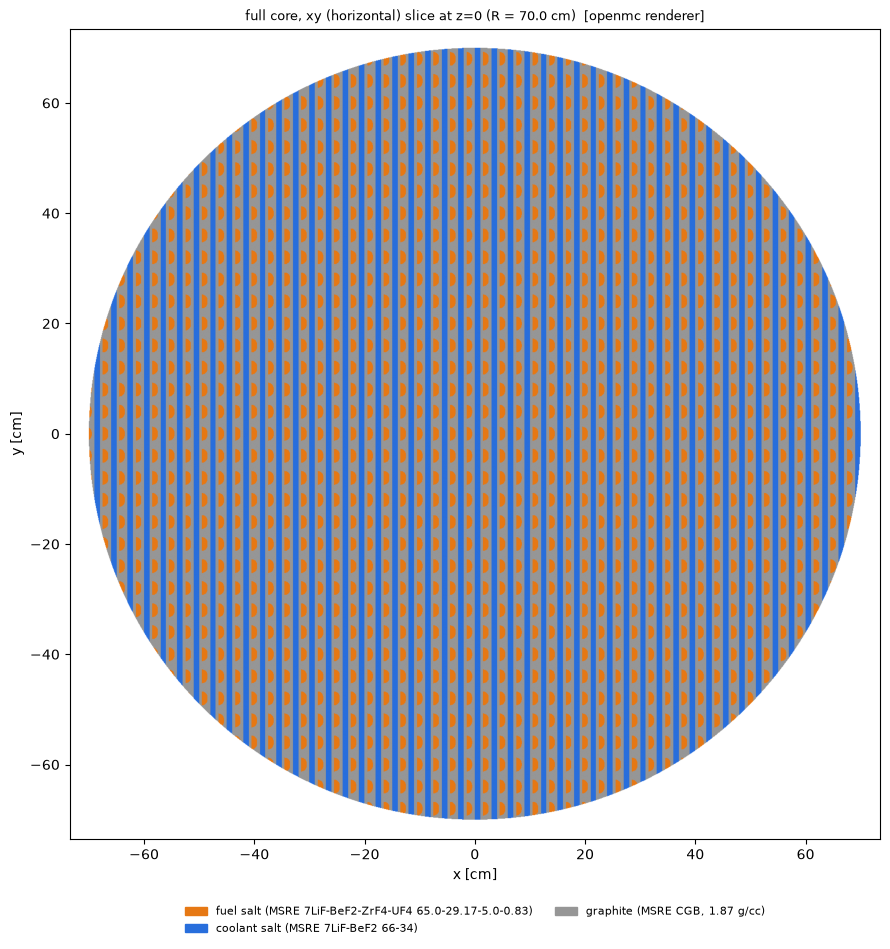

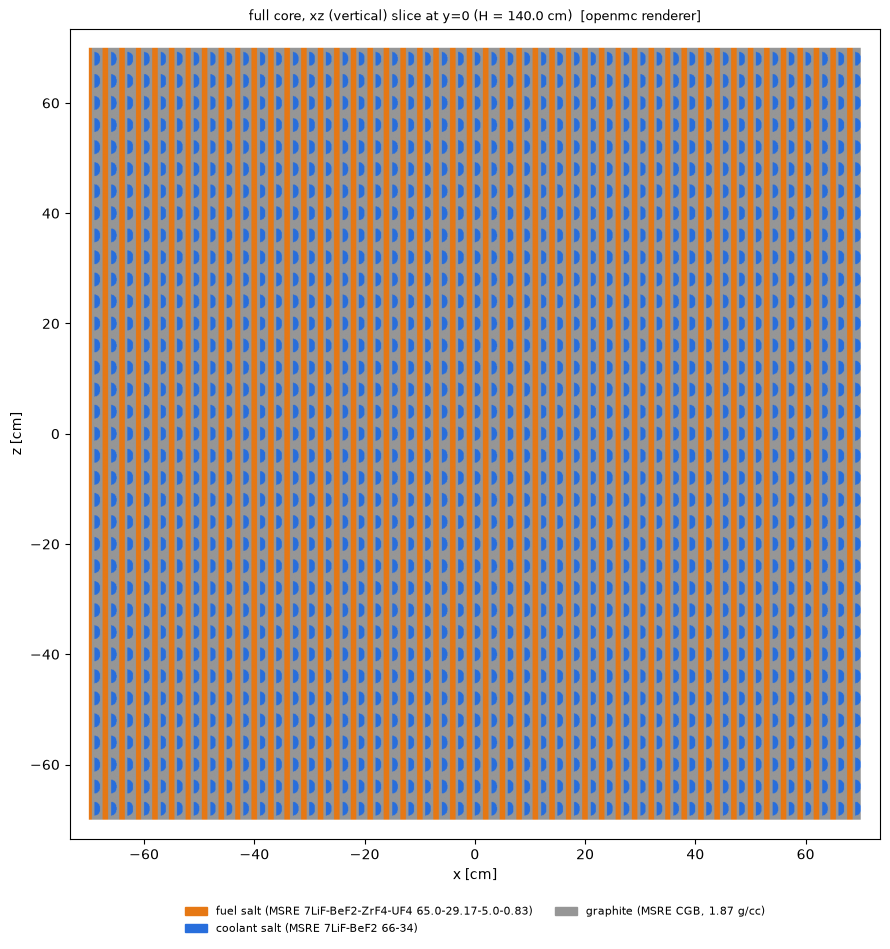

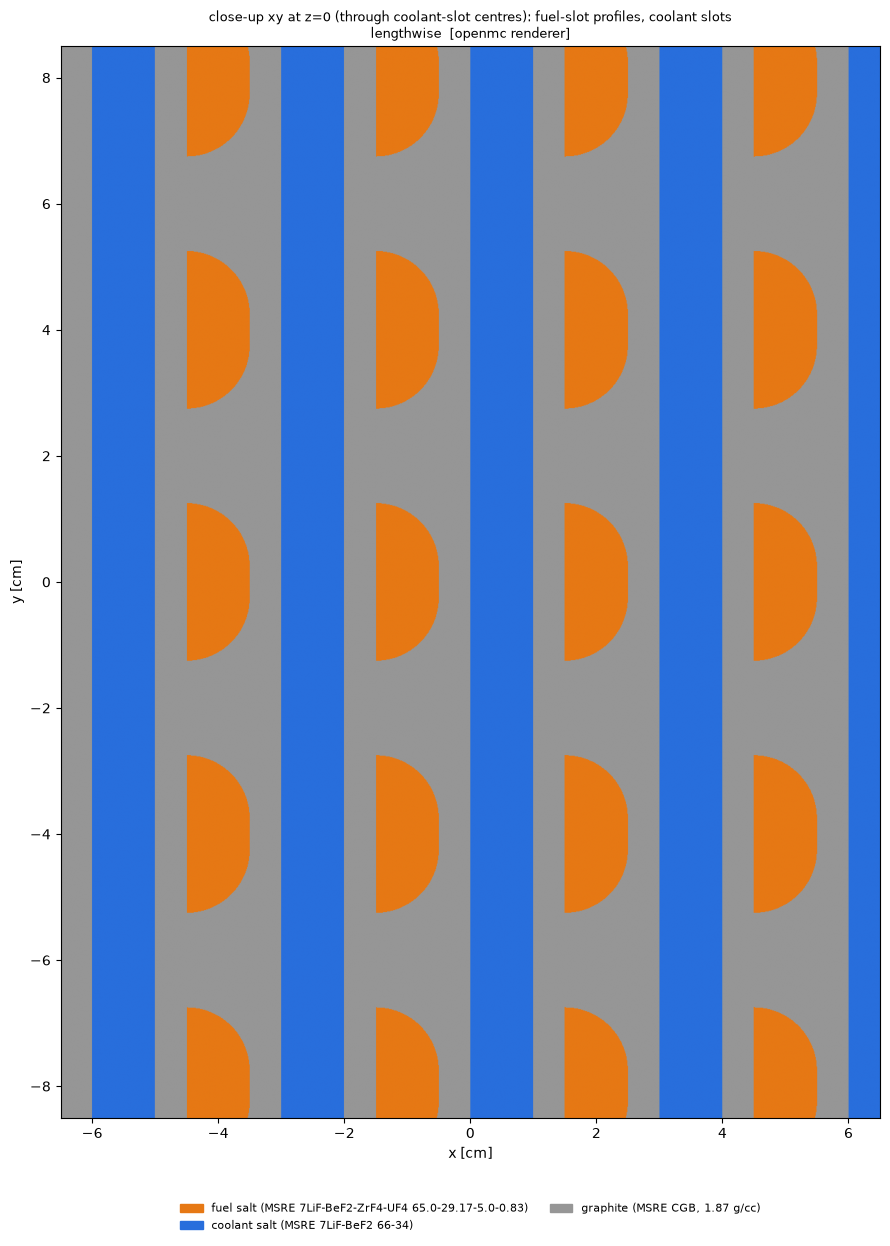

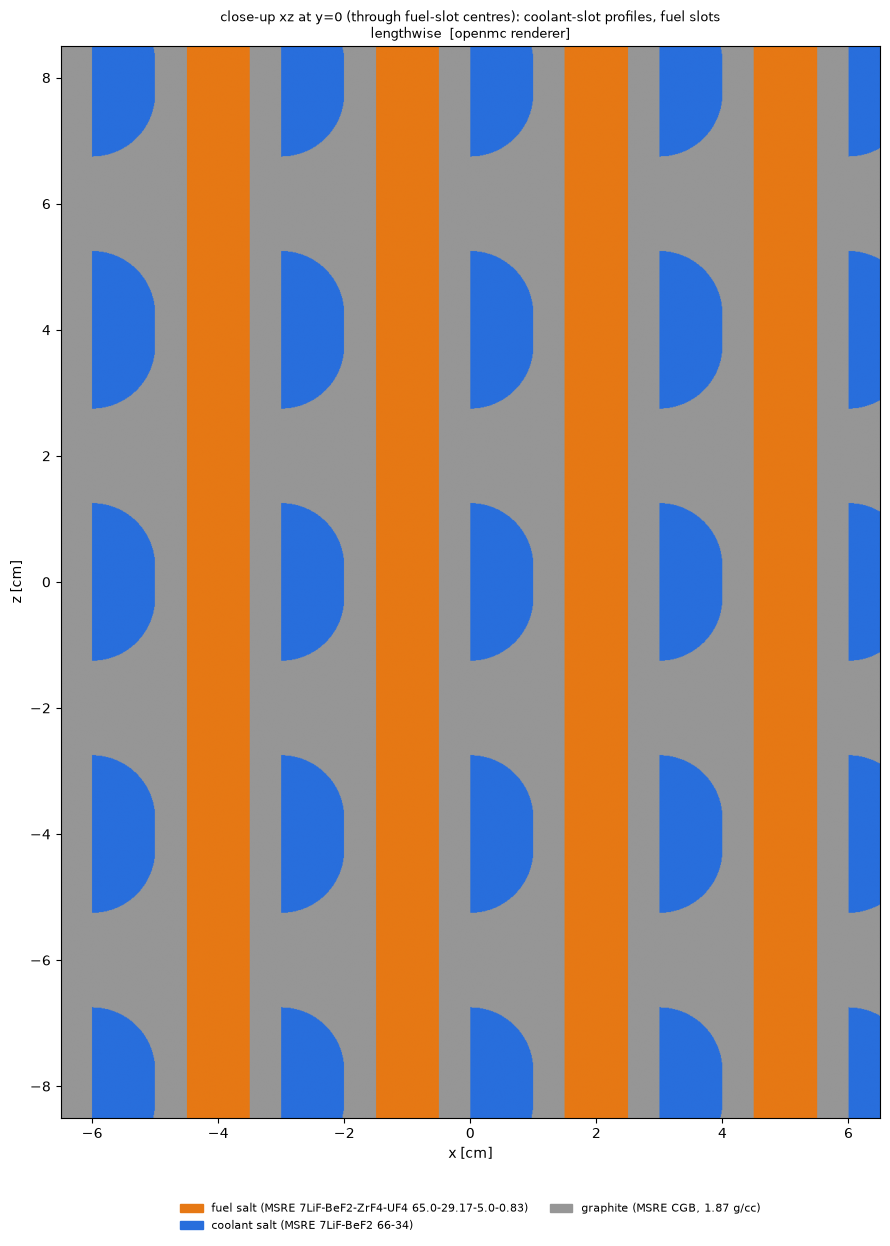

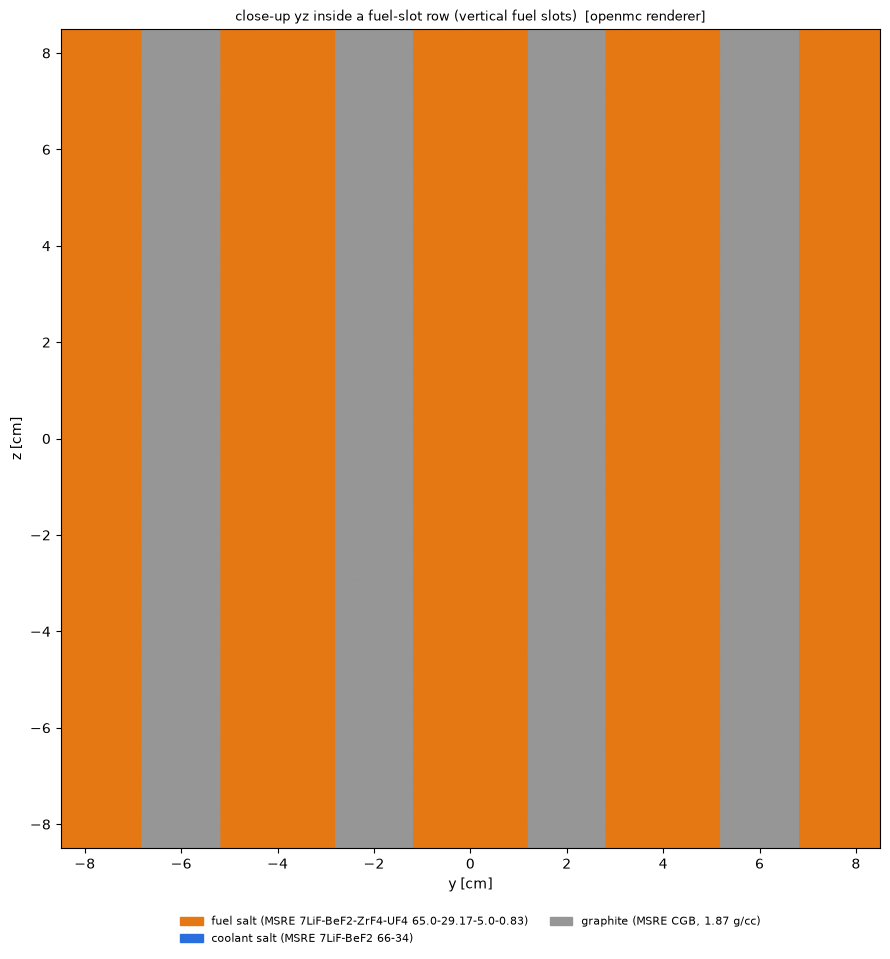

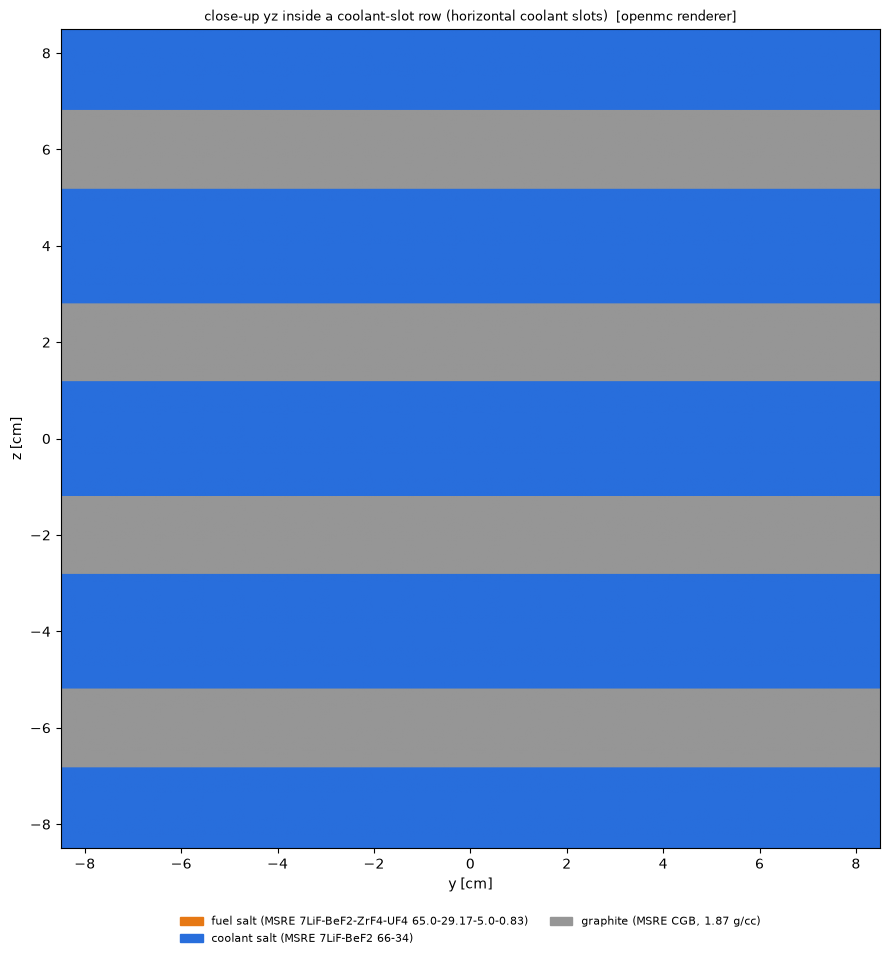

In [9]:
R_ = CORE_RADIUS + REFLECTOR_THICKNESS
Px, Py, Pz, d = p["pitch_x"], p["pitch_y"], p["pitch_z"], p["slot_depth"]
# full core
plot_slice(model, "xy", origin=(0, 0, 0), width=(2.1 * R_, 2.1 * R_), pixels=(1600, 1600),
           title=f"full core, xy (horizontal) slice at z=0 (R = {CORE_RADIUS} cm)", filename=os.path.join(WORK_DIR, "geom_core_xy.png"))
plot_slice(model, "xz", origin=(0, 0, 0), width=(2.1 * R_, 2.1 * R_), pixels=(1600, 1600),
           title=f"full core, xz (vertical) slice at y=0 (H = {2*CORE_RADIUS} cm)", filename=os.path.join(WORK_DIR, "geom_core_xz.png"))
# close-ups of the slot pattern at the core centre (a unit cell is centred on the axis)
W = (4 * Px + 1, 4 * Py + 1, 4 * Pz + 1)
x_fuel = layer_start(p, "F") + 0.35 * d      # inside the fuel-slot row of the central unit cell
x_cool = layer_start(p, "C") + 0.35 * d      # inside the coolant-slot row
plot_slice(model, "xy", origin=(0, 0, 0), width=(W[0], W[1]), pixels=(1200, int(1200 * W[1] / W[0])),
           title="close-up xy at z=0 (through coolant-slot centres): fuel-slot profiles, coolant slots lengthwise",
           filename=os.path.join(WORK_DIR, "geom_xy.png"))
plot_slice(model, "xz", origin=(0, 0, 0), width=(W[0], W[2]), pixels=(1200, int(1200 * W[2] / W[0])),
           title="close-up xz at y=0 (through fuel-slot centres): coolant-slot profiles, fuel slots lengthwise",
           filename=os.path.join(WORK_DIR, "geom_xz.png"))
plot_slice(model, "yz", origin=(x_fuel, 0, 0), width=(W[1], W[2]), pixels=(800, 800),
           title="close-up yz inside a fuel-slot row (vertical fuel slots)", filename=os.path.join(WORK_DIR, "geom_yz_fuel_row.png"))
plot_slice(model, "yz", origin=(x_cool, 0, 0), width=(W[1], W[2]), pixels=(800, 800),
           title="close-up yz inside a coolant-slot row (horizontal coolant slots)", filename=os.path.join(WORK_DIR, "geom_yz_coolant_row.png"))
plt.show()

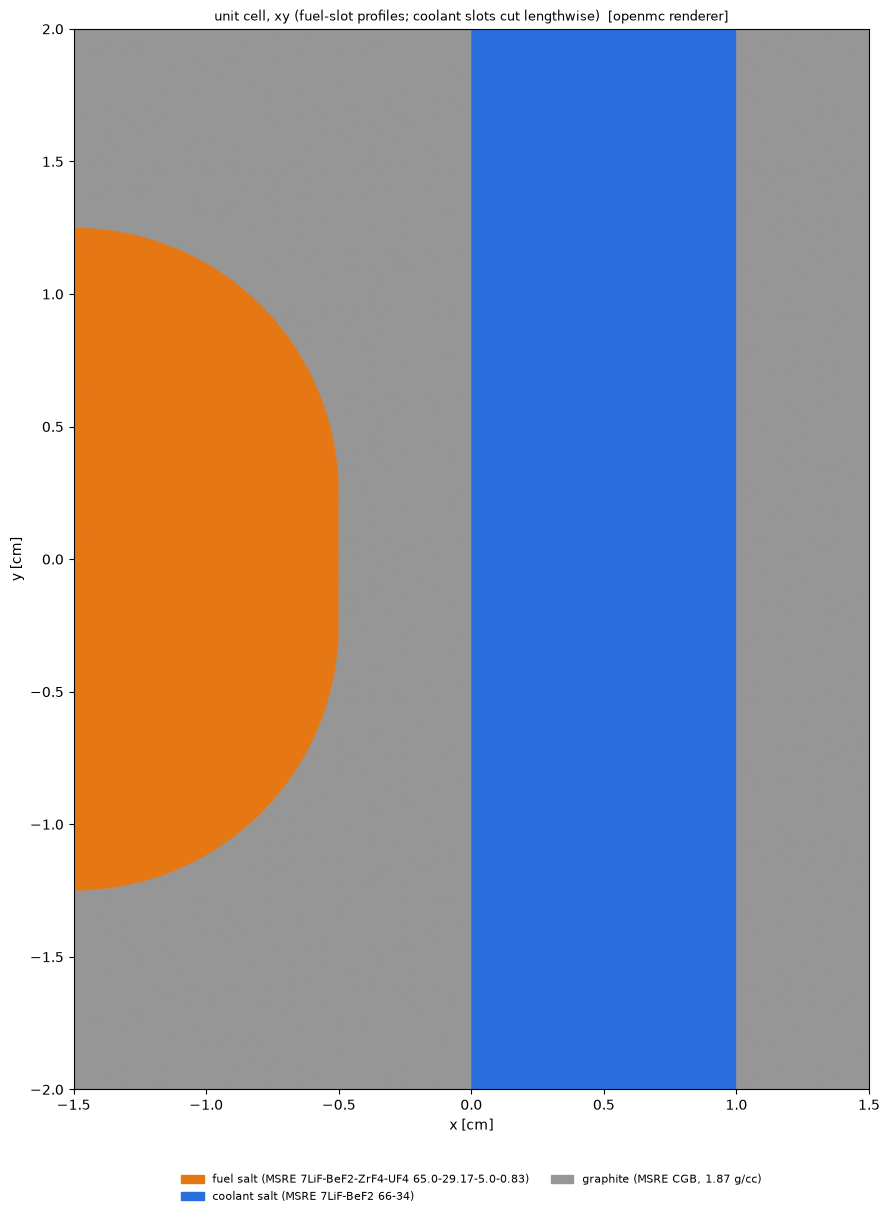

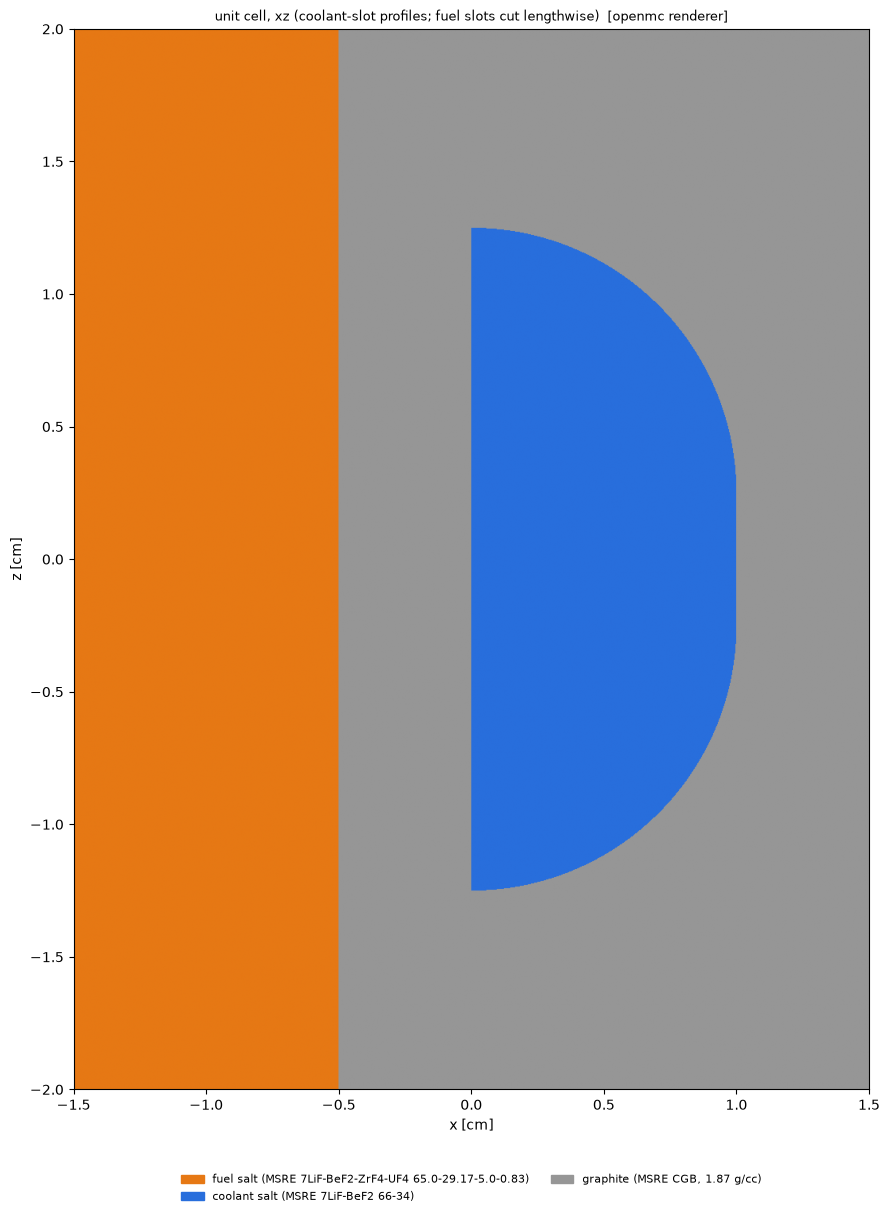

In [10]:
# zoom on ONE periodic unit cell (the k-inf model): profiles of both slot types
plot_slice(model_uc, "xy", origin=(0, 0, 0), width=(p["pitch_x"], p["pitch_y"]), pixels=(1000, int(1000 * p["pitch_y"] / p["pitch_x"])),
           title="unit cell, xy (fuel-slot profiles; coolant slots cut lengthwise)", filename=os.path.join(WORK_DIR, "geom_unitcell_xy.png"))
plot_slice(model_uc, "xz", origin=(0, 0, 0), width=(p["pitch_x"], p["pitch_z"]), pixels=(1000, int(1000 * p["pitch_z"] / p["pitch_x"])),
           title="unit cell, xz (coolant-slot profiles; fuel slots cut lengthwise)", filename=os.path.join(WORK_DIR, "geom_unitcell_xz.png"))
plt.show()

## 6. Check: CSG volumes (Monte-Carlo point sampling of the OpenMC geometry) vs. closed-form formulas
Pure Python, no nuclear data needed. Agreement within ~2σ confirms the CSG matches the intended profile.

In [11]:
rows = []
cases = [("both_sides", None, 0.5), ("both_sides", None, 0.0), ("both_sides", None, 1.5),
         ("side", 2.5, None), ("bottom", 2.0, None), ("none", 2.5, None)]
for loc, w, flat in cases:
    kw = dict(DEFAULTS, round_location=loc)
    if w is not None: kw["slot_width"] = w
    if flat is not None: kw["flat_width"] = flat
    w = resolve_params(**kw)["slot_width"]
    m = build_model(**kw, mode="unit_cell")
    mc = csg_volume_check(m, n=20000, seed=1)
    an = analytic_metrics(**kw)
    for k in ("fuel_vf", "coolant_vf", "graphite_vf"):
        rows.append(dict(round_location=loc, slot_width=w, quantity=k, analytic=an[k], csg_mc=mc[k][0],
                         sigma=mc[k][1], n_sigma=(mc[k][0] - an[k]) / mc[k][1]))
chk = pd.DataFrame(rows)
display(chk.round(4))
assert (chk["n_sigma"].abs() < 4).all(), "CSG and analytic volume fractions disagree!"

,round_location,slot_width,quantity,analytic,csg_mc,sigma,n_sigma
0,both_sides,2.5,fuel_vf,0.1726,0.1730,0.0027,0.1808
1,both_sides,2.5,coolant_vf,0.1726,0.1724,0.0027,-0.0623
2,both_sides,2.5,graphite_vf,0.6549,0.6546,0.0034,-0.0944
3,both_sides,2.0,fuel_vf,0.1496,0.1476,0.0025,-0.7772
4,both_sides,2.0,coolant_vf,0.1496,0.1496,0.0025,0.0200
5,both_sides,2.0,graphite_vf,0.7008,0.7027,0.0032,0.5877
6,both_sides,3.5,fuel_vf,0.2047,0.2048,0.0029,0.0456
7,both_sides,3.5,coolant_vf,0.2047,0.2042,0.0029,-0.1823
8,both_sides,3.5,graphite_vf,0.5906,0.5910,0.0035,0.1120
9,side,2.5,fuel_vf,0.1904,0.1920,0.0028,0.5566


## 7. First model: finite-cylinder k-eff at the default parameters (+ quick unit-cell k-inf)

In [12]:
def run_and_report(m, subdir, label):
    t0 = time.time()
    sp_path = m.run(cwd=os.path.join(WORK_DIR, subdir), output=False, threads=THREADS)
    dt = time.time() - t0
    with openmc.StatePoint(sp_path) as sp:
        k = sp.keff
        n_act = sp.n_batches - sp.n_inactive
        gt = sp.global_tallies
        names = [n.decode() if isinstance(n, bytes) else str(n) for n in gt["name"]]
        leak = float(gt["mean"][names.index("leakage")]) if "leakage" in names else None
    res = dict(case=label, keff=k.nominal_value, keff_std=k.std_dev, keff_std_pcm=k.std_dev * 1e5,
               leakage_fraction=leak, particles=m.settings.particles, batches=m.settings.batches,
               inactive=m.settings.inactive, runtime_s=dt, library=str(openmc.config.get("cross_sections")),
               enrichment_u235_wt_pct=ENRICHMENT, temperature_K=TEMPERATURE_K, **DEFAULTS,
               **{k_: v for k_, v in m.params.items() if k_ in ("mode", "core_radius", "core_height", "reflector_thickness", "lattice_shape")})
    print(f"{label}: k = {res['keff']:.5f} +/- {res['keff_std']:.5f} ({res['keff_std_pcm']:.0f} pcm)"
          + (f", leakage = {leak:.4f}" if leak is not None else "")
          + f"  [{res['particles']} particles x {n_act} active / {res['batches']} batches, {dt:.0f} s]")
    return res

baseline = []
if HAVE_XS and RUN_KINF:
    baseline.append(run_and_report(model_uc, "baseline_kinf", "unit cell (periodic) k-inf"))
if HAVE_XS and RUN_BASELINE:
    baseline.append(run_and_report(model, "baseline", f"finite cylinder R={CORE_RADIUS} cm, H={2*CORE_RADIUS} cm k-eff"))
if baseline:
    bdf = pd.DataFrame(baseline)
    bdf.to_csv(os.path.join(WORK_DIR, "baseline_results.csv"), index=False)
    with open(os.path.join(WORK_DIR, "baseline_results.json"), "w") as fh:
        json.dump(baseline, fh, indent=1, default=str)
    display(bdf[["case", "keff", "keff_std_pcm", "leakage_fraction", "particles", "batches", "inactive", "runtime_s"]].round(5))
    if len(baseline) == 2:
        kinf, keff, L = baseline[0]["keff"], baseline[1]["keff"], baseline[1]["leakage_fraction"]
        print(f"k_eff / k_inf = {keff / kinf:.3f}   (1 - leakage = {1 - L:.3f}); "
              f"the bare R = {CORE_RADIUS} cm core is {'sub' if keff < 1 else 'super'}critical by {abs(keff - 1) * 1e5:.0f} pcm")
else:
    print("baseline transport skipped (HAVE_XS =", HAVE_XS, ")")

unit cell (periodic) k-inf: k = 1.58746 +/- 0.00111 (111 pcm), leakage = 0.0000  [10000 particles x 60 active / 100 batches, 85 s]


finite cylinder R=70.0 cm, H=140.0 cm k-eff: k = 0.84793 +/- 0.00117 (117 pcm), leakage = 0.4423  [10000 particles x 60 active / 100 batches, 58 s]


,case,keff,keff_std_pcm,leakage_fraction,particles,batches,inactive,runtime_s
0,unit cell (periodic) k-inf,1.58746,110.78220,0.00000,10000,100,40,85.47622
1,"finite cylinder R=70.0 cm, H=140.0 cm k-eff",0.84793,117.30009,0.44234,10000,100,40,58.04442


k_eff / k_inf = 0.534   (1 - leakage = 0.558); the bare R = 70.0 cm core is subcritical by 15207 pcm


## 8. Latin-hypercube sampling of the four geometry parameters
* Sampled: `slot_depth` d, `flat_width`, `web_thickness`, `wall_thickness`; the slot width is **derived**, `w = 2d + flat_width`.
* `LHS_BOUNDS` — (low, high) in cm for each free parameter; `FIXED` — hold any parameter constant (it is removed from the hypercube).
* With the double-rounded profile every sample is feasible by construction (the feasibility filter is kept for legacy profiles).
* Each feasible sample gets its own directory `lhs_runs/sample_XXX/` with `model.xml` + `params.json` (+ statepoint if run).

In [13]:
PARAM_NAMES = ("slot_depth", "flat_width", "web_thickness", "wall_thickness")   # sampled geometry (cm)
# slot width is DERIVED: w = 2*slot_depth + flat_width (default round_location='both_sides')
OPTIONAL_PARAMS = ("enrichment", "core_radius")   # U-235 wt% of U, cylinder radius R (cm): sampled only if in bounds
ALL_PARAMS = PARAM_NAMES + OPTIONAL_PARAMS

def lhs_samples(bounds, n_samples, seed=None, fixed=None, geometry_opts=None, defaults=None, optimization=None):
    """Latin-hypercube samples.

    bounds   : {name: (low, high)} for every parameter to vary. The four geometry parameters must each be
               in `bounds` or `fixed`; 'enrichment' (U-235 wt%) and 'core_radius' (cm, H = 2R) are varied only
               if they appear in `bounds`, otherwise they take fixed[...] or defaults[...].
    fixed    : {name: value} parameters held constant (excluded from the hypercube)
    Returns a DataFrame with a 'feasible' flag and the reason for infeasible rows.
    """
    fixed = dict(fixed or {}); geometry_opts = dict(geometry_opts or {})
    defaults = {"enrichment": None, "core_radius": 70.0, **(defaults or {})}
    unknown = (set(bounds) | set(fixed)) - set(ALL_PARAMS)
    if unknown:
        raise ValueError(f"unknown parameter(s): {unknown}; allowed: {ALL_PARAMS}")
    free = [k for k in ALL_PARAMS if k in bounds and k not in fixed]
    missing = [k for k in PARAM_NAMES if k not in bounds and k not in fixed]
    if missing:
        raise ValueError(f"need bounds (or a fixed value) for {missing}")
    for k in free:
        lo, hi = bounds[k]
        if not ((0 <= lo < hi) if k == "flat_width" else (0 < lo < hi)):
            raise ValueError(f"bad bounds for {k}: {bounds[k]}")
    if "enrichment" in free and bounds["enrichment"][1] > 100:
        raise ValueError("enrichment is U-235 wt% of U: upper bound must be <= 100")
    if free:
        try:
            sampler = qmc.LatinHypercube(d=len(free), rng=seed, optimization=optimization)
        except TypeError:                                     # older SciPy
            sampler = qmc.LatinHypercube(d=len(free), seed=seed, optimization=optimization)
        unit = sampler.random(n_samples)
        vals = qmc.scale(unit, [bounds[k][0] for k in free], [bounds[k][1] for k in free])
    else:
        vals = np.empty((n_samples, 0))
    df = pd.DataFrame(vals, columns=free)
    for k, v in fixed.items():
        df[k] = float(v)
    for k in OPTIONAL_PARAMS:
        if k not in df:
            df[k] = defaults[k]
    df = df[list(ALL_PARAMS)]
    feas = [is_feasible(**{k: row[k] for k in PARAM_NAMES}, **geometry_opts) for row in df.to_dict("records")]
    df.insert(2, "slot_width", [resolve_params(**{k: r[k] for k in PARAM_NAMES}, **geometry_opts)["slot_width"]
                                if f else np.nan for r, (f, _) in zip(df.to_dict("records"), feas)])
    df["feasible"] = [f for f, _ in feas]
    df["reason"] = [r for _, r in feas]
    df.index.name = "sample"
    return df

def run_lhs(samples, work_dir, geometry_opts=None, run_opts=None, run_transport=False,
            threads=None, keep_going=True):
    """Build (and optionally run) one model per feasible sample in work_dir/sample_XXX."""
    geometry_opts = dict(geometry_opts or {}); run_opts = dict(run_opts or {})
    os.makedirs(work_dir, exist_ok=True)
    rows = []
    for idx, s in samples[samples["feasible"]].iterrows():
        geo = {k: float(s[k]) for k in PARAM_NAMES}
        enr = None if pd.isna(s.get("enrichment", np.nan)) else float(s["enrichment"])
        rad = float(s["core_radius"])
        d = os.path.join(work_dir, f"sample_{idx:03d}")
        os.makedirs(d, exist_ok=True)
        row = {"sample": idx, **geo, "enrichment": enr if enr is not None else MSRE_U235_WT_PCT,
               "core_radius": rad, **analytic_metrics(**geo, core_radius=rad, **geometry_opts), "keff": np.nan, "keff_std": np.nan,
               "runtime_s": np.nan, "status": "built"}
        try:
            model = build_model(**geo, enrichment=enr, core_radius=rad, **geometry_opts, **run_opts)
            model.export_to_model_xml(os.path.join(d, "model.xml"))
            with open(os.path.join(d, "params.json"), "w") as f:
                json.dump({**geo, "enrichment_u235_wt_pct": row["enrichment"], "core_radius": rad,
                       **geometry_opts, **run_opts}, f, indent=1)
            if run_transport:
                t0 = time.time()
                sp_path = model.run(cwd=d, output=False, threads=threads)
                row["runtime_s"] = time.time() - t0
                with openmc.StatePoint(sp_path) as sp:
                    row["keff"], row["keff_std"] = sp.keff.nominal_value, sp.keff.std_dev
                row["status"] = "ran"
        except Exception as e:
            row["status"] = f"error: {e}"
            if not keep_going:
                raise
        rows.append(row)
        print(f"sample {idx:3d}: " + ", ".join(f"{k}={geo[k]:.3f}" for k in PARAM_NAMES) + f", w={row['slot_width']:.3f}"
              + f", enr={row['enrichment']:.2f}, R={rad:.1f} | fuel_vf={row['fuel_vf']:.3f} C/F={row['graphite_to_fuel']:.2f}"
              + (f" | k={row['keff']:.5f}+/-{row['keff_std']:.5f} ({row['runtime_s']:.0f}s)" if row['status'] == 'ran' else f" | {row['status']}"))
    return pd.DataFrame(rows).set_index("sample")

12 / 12 samples feasible


,slot_depth,flat_width,slot_width,web_thickness,wall_thickness,enrichment,core_radius,feasible,reason
sample,,,,,,,,,
0,1.162,1.372,3.696,1.207,0.847,33.477,70.0,True,
1,0.923,0.268,2.115,1.937,1.303,33.477,70.0,True,
2,0.880,1.212,2.971,1.544,1.051,33.477,70.0,True,
3,1.416,0.917,3.750,1.807,0.346,33.477,70.0,True,
4,1.788,1.031,4.608,0.800,1.146,33.477,70.0,True,
5,1.217,0.858,3.292,1.361,0.702,33.477,70.0,True,
6,1.064,1.475,3.602,1.188,0.642,33.477,70.0,True,
7,1.604,0.476,3.684,1.639,0.562,33.477,70.0,True,
8,1.860,0.241,3.961,1.758,0.443,33.477,70.0,True,


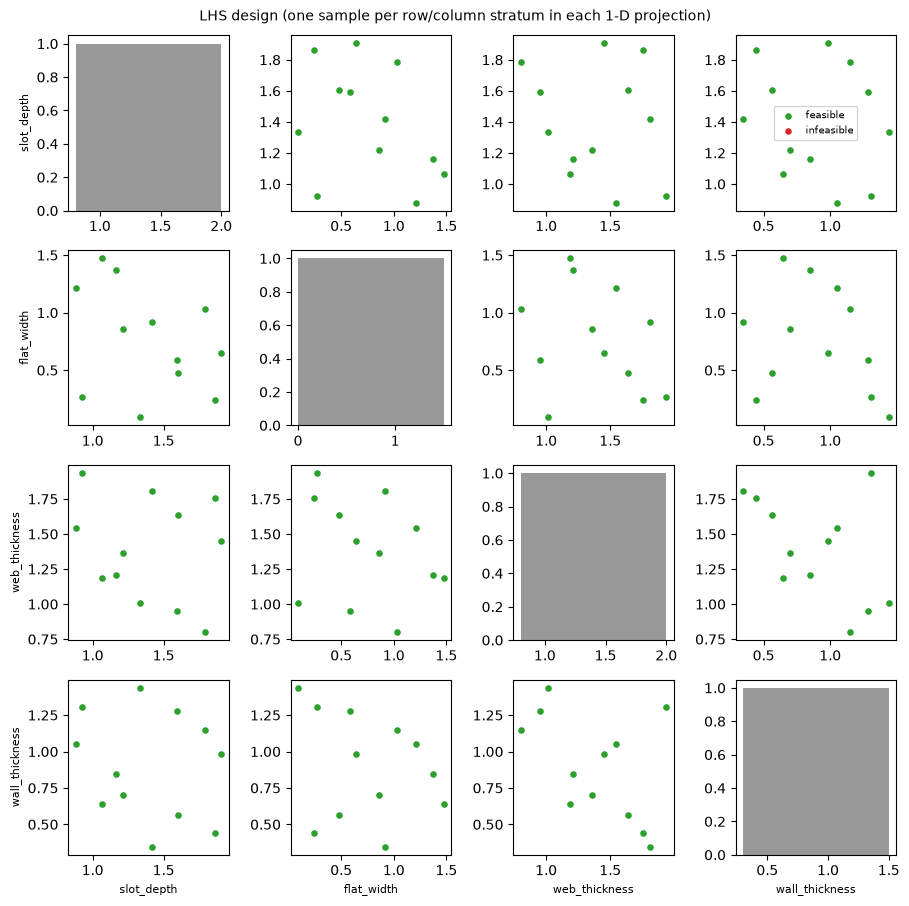

In [14]:
LHS_BOUNDS = {
    "slot_depth":     (0.8, 2.0),
    "flat_width":     (0.0, 1.5),     # slot width w = 2*slot_depth + flat_width  (1.6 - 5.5 cm)
    "web_thickness":  (0.8, 2.0),
    "wall_thickness": (0.3, 1.5),     # 3 mm practical floor (see wall-thickness note)
    # "enrichment":   (5.0, 33.477),   # optional: U-235 wt% of U (off -> ENRICHMENT for every sample)
    # "core_radius":  (50.0, 100.0),   # optional: cylinder radius R in cm, H = 2R (off -> CORE_RADIUS)
}
FIXED = {}                  # e.g. {"wall_thickness": 0.5}
N_SAMPLES, LHS_SEED = 12, 2026
LHS_DIR = os.path.join(WORK_DIR, "lhs_runs")

samples = lhs_samples({k: v for k, v in LHS_BOUNDS.items() if k not in FIXED}, N_SAMPLES, seed=LHS_SEED,
                      fixed=FIXED, geometry_opts=GEOM_OPTS, defaults={"enrichment": ENRICHMENT, "core_radius": CORE_RADIUS})
print(f"{samples['feasible'].sum()} / {len(samples)} samples feasible")
display(samples.round(3))

free = [k for k in ALL_PARAMS if k in LHS_BOUNDS and k not in FIXED]
fig, axs = plt.subplots(len(free), len(free), figsize=(2.3 * len(free), 2.3 * len(free)), squeeze=False)
for i, a in enumerate(free):
    for j, b in enumerate(free):
        ax = axs[i, j]
        if i == j:
            ax.hist(samples[a], bins=N_SAMPLES, range=LHS_BOUNDS[a], color="0.6")
        else:
            for f, c in [(True, "tab:green"), (False, "tab:red")]:
                s = samples[samples["feasible"] == f]
                ax.scatter(s[b], s[a], s=14, c=c, label="feasible" if f else "infeasible")
        if i == len(free) - 1: ax.set_xlabel(b, fontsize=8)
        if j == 0: ax.set_ylabel(a, fontsize=8)
axs[0, -1].legend(fontsize=7)
fig.suptitle("LHS design (one sample per row/column stratum in each 1-D projection)", fontsize=10)
fig.tight_layout(); fig.savefig(os.path.join(WORK_DIR, "lhs_design.png"), dpi=130); plt.show()

In [15]:
do_run = RUN_TRANSPORT and HAVE_XS
if RUN_TRANSPORT and not HAVE_XS:
    print("RUN_TRANSPORT requested but no cross_sections.xml -> building models + analytic metrics only")
results = run_lhs(samples, LHS_DIR, geometry_opts=GEOM_OPTS_CORE, run_opts=RUN_OPTS, run_transport=do_run, threads=THREADS)
csv_path = os.path.join(WORK_DIR, "lhs_results.csv")
results.to_csv(csv_path)
print("saved", csv_path)
display(results[list(PARAM_NAMES) + ["slot_width"] + list(OPTIONAL_PARAMS) + ["fuel_vf", "coolant_vf", "graphite_vf", "graphite_to_fuel", "keff", "keff_std", "runtime_s", "status"]].round(4))

sample   0: slot_depth=1.162, flat_width=1.372, web_thickness=1.207, wall_thickness=0.847, w=3.696, enr=33.48, R=70.0 | fuel_vf=0.189 C/F=3.30 | built
sample   1: slot_depth=0.923, flat_width=0.268, web_thickness=1.937, wall_thickness=1.303, w=2.115, enr=33.48, R=70.0 | fuel_vf=0.088 C/F=9.37 | built
sample   2: slot_depth=0.880, flat_width=1.212, web_thickness=1.544, wall_thickness=1.051, w=2.971, enr=33.48, R=70.0 | fuel_vf=0.131 C/F=5.64 | built
sample   3: slot_depth=1.416, flat_width=0.917, web_thickness=1.807, wall_thickness=0.346, w=3.750, enr=33.48, R=70.0 | fuel_vf=0.227 C/F=2.40 | built
sample   4: slot_depth=1.788, flat_width=1.031, web_thickness=0.800, wall_thickness=1.146, w=4.608, enr=33.48, R=70.0 | fuel_vf=0.216 C/F=2.62 | built
sample   5: slot_depth=1.217, flat_width=0.858, web_thickness=1.361, wall_thickness=0.702, w=3.292, enr=33.48, R=70.0 | fuel_vf=0.189 C/F=3.30 | built


sample   6: slot_depth=1.064, flat_width=1.475, web_thickness=1.188, wall_thickness=0.642, w=3.602, enr=33.48, R=70.0 | fuel_vf=0.205 C/F=2.88 | built
sample   7: slot_depth=1.604, flat_width=0.476, web_thickness=1.639, wall_thickness=0.562, w=3.684, enr=33.48, R=70.0 | fuel_vf=0.208 C/F=2.80 | built
sample   8: slot_depth=1.860, flat_width=0.241, web_thickness=1.758, wall_thickness=0.443, w=3.961, enr=33.48, R=70.0 | fuel_vf=0.223 C/F=2.48 | built
sample   9: slot_depth=1.906, flat_width=0.645, web_thickness=1.447, wall_thickness=0.985, w=4.457, enr=33.48, R=70.0 | fuel_vf=0.203 C/F=2.92 | built
sample  10: slot_depth=1.596, flat_width=0.586, web_thickness=0.948, wall_thickness=1.281, w=3.777, enr=33.48, R=70.0 | fuel_vf=0.181 C/F=3.51 | built
sample  11: slot_depth=1.334, flat_width=0.090, web_thickness=1.011, wall_thickness=1.440, w=2.757, enr=33.48, R=70.0 | fuel_vf=0.139 C/F=5.17 | built
saved /workspace/msr_slab/lhs_results.csv


,slot_depth,flat_width,web_thickness,wall_thickness,slot_width,enrichment,core_radius,fuel_vf,coolant_vf,graphite_vf,graphite_to_fuel,keff,keff_std,runtime_s,status
sample,,,,,,,,,,,,,,,
0,1.1617,1.3724,1.2068,0.8473,3.6959,33.477,70.0,0.1886,0.1886,0.6229,3.3036,NaN,NaN,NaN,built
1,0.9231,0.2683,1.9368,1.3033,2.1145,33.477,70.0,0.0879,0.0879,0.8241,9.3731,NaN,NaN,NaN,built
2,0.8795,1.2120,1.5439,1.0506,2.9711,33.477,70.0,0.1309,0.1309,0.7382,5.6406,NaN,NaN,NaN,built
3,1.4160,0.9175,1.8070,0.3455,3.7495,33.477,70.0,0.2273,0.2273,0.5455,2.4003,NaN,NaN,NaN,built
4,1.7883,1.0310,0.8002,1.1464,4.6077,33.477,70.0,0.2164,0.2164,0.5673,2.6219,NaN,NaN,NaN,built
5,1.2168,0.8584,1.3612,0.7016,3.2920,33.477,70.0,0.1888,0.1888,0.6224,3.2973,NaN,NaN,NaN,built
6,1.0637,1.4748,1.1879,0.6424,3.6023,33.477,70.0,0.2047,0.2047,0.5906,2.8848,NaN,NaN,NaN,built
7,1.6040,0.4760,1.6390,0.5617,3.6840,33.477,70.0,0.2084,0.2084,0.5832,2.7985,NaN,NaN,NaN,built
8,1.8599,0.2412,1.7576,0.4433,3.9609,33.477,70.0,0.2233,0.2233,0.5534,2.4783,NaN,NaN,NaN,built


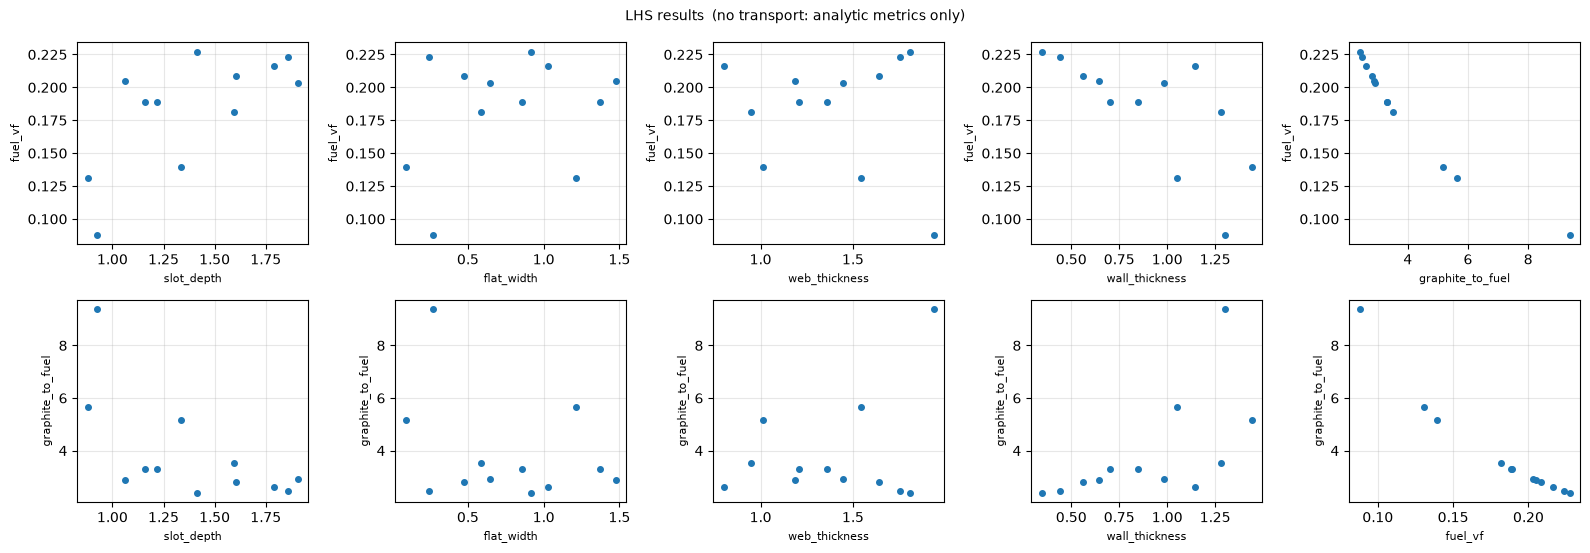

In [16]:
have_k = results["keff"].notna().any()
XCOLS = list(PARAM_NAMES) + [c for c in OPTIONAL_PARAMS if results[c].nunique() > 1]
ycols = ["keff"] if have_k else []
ycols += ["fuel_vf", "graphite_to_fuel"]
fig, axs = plt.subplots(len(ycols), len(XCOLS) + 1, figsize=(3.2 * (len(XCOLS) + 1), 2.8 * len(ycols)), squeeze=False)
for r, y in enumerate(ycols):
    for c, x in enumerate(XCOLS + ["graphite_to_fuel"] if y != "graphite_to_fuel" else XCOLS + ["fuel_vf"]):
        ax = axs[r, c]
        if y == "keff":
            ax.errorbar(results[x], results["keff"], yerr=results["keff_std"], fmt="o", ms=4, capsize=2)
        else:
            ax.plot(results[x], results[y], "o", ms=4)
        ax.set_xlabel(x, fontsize=8); ax.set_ylabel(y, fontsize=8); ax.grid(alpha=0.3)
fig.suptitle("LHS results" + ("" if have_k else "  (no transport: analytic metrics only)"), fontsize=10)
fig.tight_layout(); fig.savefig(os.path.join(WORK_DIR, "lhs_results.png"), dpi=130); plt.show()

# LHS summary (12 feasible of 12 samples, seed 2026)

Lengths in cm; slot_width = 2*slot_depth + flat_width. round_location=both_sides, stacking=plates, mode=cylinder, R=70.0 cm (H=2R) unless varied, reflector=0.0 cm, enrichment 33.477 wt% U-235 unless varied, T = 922.0 K, 10000 particles x 100 batches (40 inactive), library: /workspace/nucdata/endfb-viii.0-hdf5/cross_sections.xml

| sample | slot_depth | flat_width | web_thickness | wall_thickness | slot_width | enrichment | core_radius | fuel_vf | coolant_vf | graphite_to_fuel | keff | keff_std_pcm | runtime_s | status |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 1.162 | 1.372 | 1.207 | 0.847 | 3.696 | 33.477 | 70.0 | 0.1886 | 0.1886 | 3.30 | - | - | - | built |
| 1 | 0.923 | 0.268 | 1.937 | 1.303 | 2.115 | 33.477 | 70.0 | 0.0879 | 0.0879 | 9.37 | - | - | - | built |
| 2 | 0.880 | 1.212 | 1.544 | 1.051 | 2.971 | 33.477 | 70.0 | 0.1309 | 0.1309 | 5.64 | - | - | - | built |
| 3 | 1.416 | 0.917 | 1.807 | 0.346 |

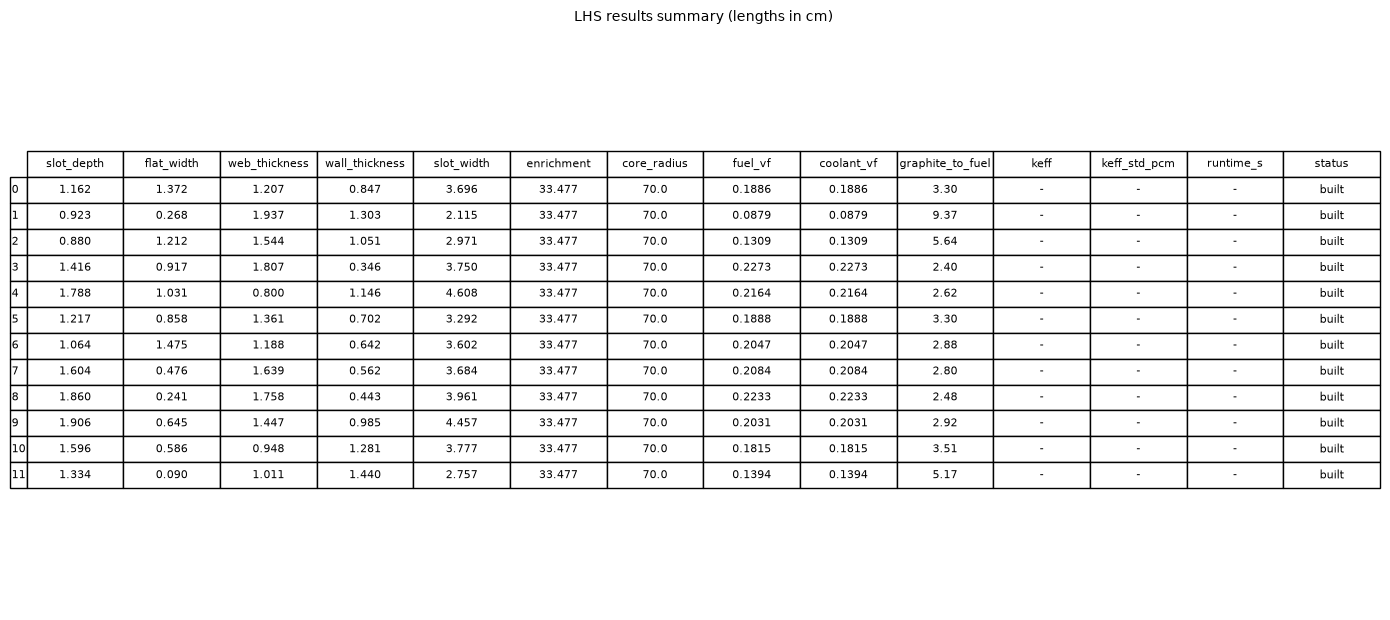

In [17]:
# keff vs each parameter (own figure) + summary table (markdown + PNG)
if have_k:
    xs = XCOLS + ["graphite_to_fuel"]
    fig, axs = plt.subplots(1, len(xs), figsize=(3.4 * len(xs), 3.4), sharey=True)
    for ax, x in zip(axs, xs):
        ax.errorbar(results[x], results["keff"], yerr=results["keff_std"], fmt="o", ms=5, capsize=3)
        for i, r in results.iterrows():
            ax.annotate(str(i), (r[x], r["keff"]), fontsize=6, xytext=(3, 3), textcoords="offset points")
        ax.set_xlabel(x + (" [cm]" if x in PARAM_NAMES else " [U-235 wt%]" if x == "enrichment" else " [cm]" if x == "core_radius" else " (V_gr / V_fuel)")); ax.grid(alpha=0.3)
    axs[0].set_ylabel("k-eff" if MODE == "cylinder" else "k-inf")
    fig.suptitle(f"{'finite-cylinder k-eff' if MODE == 'cylinder' else 'k-inf'} vs parameters (LHS, {len(results)} feasible samples, {PARTICLES} particles x {BATCHES-INACTIVE} active batches)", fontsize=10)
    fig.tight_layout(); fig.savefig(os.path.join(WORK_DIR, "keff_vs_params.png"), dpi=140); plt.show()

cols = list(PARAM_NAMES) + ["slot_width"] + list(OPTIONAL_PARAMS) + ["fuel_vf", "coolant_vf", "graphite_to_fuel", "keff", "keff_std", "runtime_s", "status"]
summ = results[cols].copy()
summ["keff_std_pcm"] = summ["keff_std"] * 1e5
summ = summ[list(PARAM_NAMES) + ["slot_width"] + list(OPTIONAL_PARAMS) + ["fuel_vf", "coolant_vf", "graphite_to_fuel", "keff", "keff_std_pcm", "runtime_s", "status"]]
fmt = {c: "{:.3f}" for c in PARAM_NAMES + ("slot_width",)} | {"enrichment": "{:.3f}", "core_radius": "{:.1f}", "runtime_s": "{:.0f}", "fuel_vf": "{:.4f}", "coolant_vf": "{:.4f}", "graphite_to_fuel": "{:.2f}",
                                          "keff": "{:.5f}", "keff_std_pcm": "{:.0f}"}
tbl = summ.copy()
for c, f in fmt.items():
    tbl[c] = [f.format(v) if pd.notna(v) else "-" for v in summ[c]]
md_path = os.path.join(WORK_DIR, "lhs_summary.md")
with open(md_path, "w") as fh:
    fh.write(f"# LHS summary ({len(results)} feasible of {len(samples)} samples, seed {LHS_SEED})\n\n")
    fh.write(f"Lengths in cm; slot_width = 2*slot_depth + flat_width. round_location={GEOM_OPTS['round_location']}, stacking={GEOM_OPTS['stacking']}, "
             f"mode={MODE}, R={CORE_RADIUS} cm (H=2R) unless varied, reflector={REFLECTOR_THICKNESS} cm, "
             f"enrichment {ENRICHMENT} wt% U-235 unless varied, T = {TEMPERATURE_K} K, "
             f"{PARTICLES} particles x {BATCHES} batches ({INACTIVE} inactive), library: {openmc.config.get('cross_sections') if HAVE_XS else 'none'}\n\n")
    hdr = ["sample"] + list(tbl.columns)                      # plain markdown table (no 'tabulate' dependency)
    fh.write("| " + " | ".join(hdr) + " |\n|" + "---|" * len(hdr) + "\n")
    for i, r in tbl.iterrows():
        fh.write("| " + " | ".join([str(i)] + [str(v) for v in r.values]) + " |\n")
    fh.write("\n")
print(open(md_path).read())
fig, ax = plt.subplots(figsize=(14, 0.45 * (len(tbl) + 2)))
ax.axis("off")
t = ax.table(cellText=tbl.values, colLabels=list(tbl.columns), rowLabels=[str(i) for i in tbl.index], loc="center", cellLoc="center")
t.auto_set_font_size(False); t.set_fontsize(8); t.scale(1, 1.3)
ax.set_title("LHS results summary (lengths in cm)", fontsize=10)
fig.tight_layout(); fig.savefig(os.path.join(WORK_DIR, "lhs_summary_table.png"), dpi=150); plt.show()

## 9. Depth scans — does a shallower slot improve k-eff?
Two one-at-a-time scans, holding `flat_width = 0.5`, `web_thickness = 1.5`, `wall_thickness = 0.5` cm, with the same model as the
baseline (`both_sides` profile, plate stacking, bare cylinder R = 70 cm, H = 2R, default enrichment, 10 000 particles × 100 batches, 40 inactive):

* **Common depth scan:** fuel and coolant slot depth together, `d = 0.6, 0.8, 1.0, 1.2` cm (`w = 2d + flat`; the pitch shrinks with `d`).
* **Coolant-only depth scan:** fuel depth fixed at 1.0 cm, `coolant_depth = 0.6 … 1.2` cm (coolant width `w_c = 2 d_c + flat`).
  With `coolant_depth ≠ slot_depth` the unit cell stays consistent: the coolant layer is `d_c` thick
  (`P_x = d + d_c + 2·wall`), fuel slots repeat along y with `P_y = w + web`, coolant slots along z with `P_z = w_c + web`
  (one web thickness everywhere). `coolant_depth=None` (default) = identical slots.

The scans were run with `dev/depth_scan.py common|coolant`; this cell **loads** `results/depth_scan.csv` and
`results/coolant_depth_scan.csv` (set `RUN_DEPTH_SCAN = True` to recompute them here, ~10 min each).
Core fuel volume = fuel volume fraction × cylinder volume (2155 L); fuel mass uses the MSRE fuel-salt density at 922 K.


common depth scan:


,slot_depth,coolant_depth,slot_width,coolant_slot_width,kinf,kinf_std,keff,keff_std,leakage_fraction,fuel_vf,coolant_vf,graphite_vf,graphite_to_fuel,core_fuel_volume_l,core_fuel_mass_kg
0,0.6,0.6,1.7,1.7,1.61803,0.00096,0.82268,0.00138,0.47055,0.12294,0.12294,0.75412,6.13415,264.94865,594.05196
1,0.8,0.8,2.1,2.1,1.60207,0.00110,0.84369,0.00121,0.45282,0.15014,0.15014,0.69972,4.66045,323.57143,725.49243
2,1.0,1.0,2.5,2.5,1.58746,0.00111,0.84793,0.00117,0.44234,0.17257,0.17257,0.65487,3.79487,371.90338,833.85943
3,1.2,1.2,2.9,2.9,1.57201,0.00110,0.85105,0.00113,0.43633,0.19131,0.19131,0.61739,3.22721,412.29108,924.41430


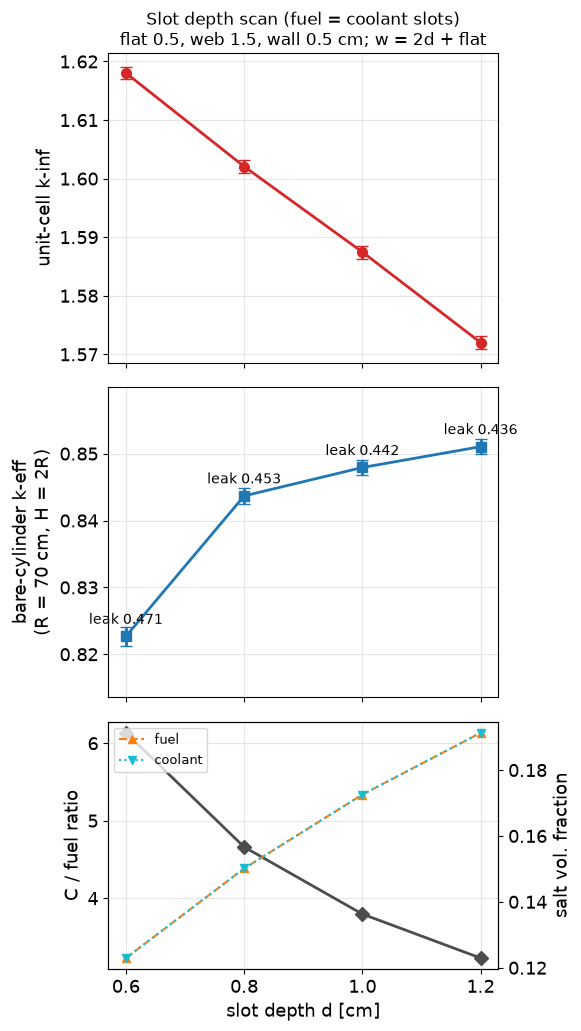


coolant depth scan:


,slot_depth,coolant_depth,slot_width,coolant_slot_width,kinf,kinf_std,keff,keff_std,leakage_fraction,fuel_vf,coolant_vf,graphite_vf,graphite_to_fuel,core_fuel_volume_l,core_fuel_mass_kg
0,1.0,0.6,2.5,1.7,1.60414,0.00104,0.88981,0.00137,0.42223,0.19912,0.10402,0.69686,3.49979,429.11929,962.14550
1,1.0,0.8,2.5,2.1,1.59569,0.00110,0.86889,0.00133,0.43265,0.18489,0.13942,0.67569,3.65451,398.46791,893.42082
2,1.0,1.0,2.5,2.5,1.58746,0.00111,0.84793,0.00117,0.44234,0.17257,0.17257,0.65487,3.79487,371.90338,833.85943
3,1.0,1.2,2.5,2.9,1.57161,0.00112,0.82498,0.00131,0.45298,0.16178,0.20326,0.63496,3.92479,348.65942,781.74322


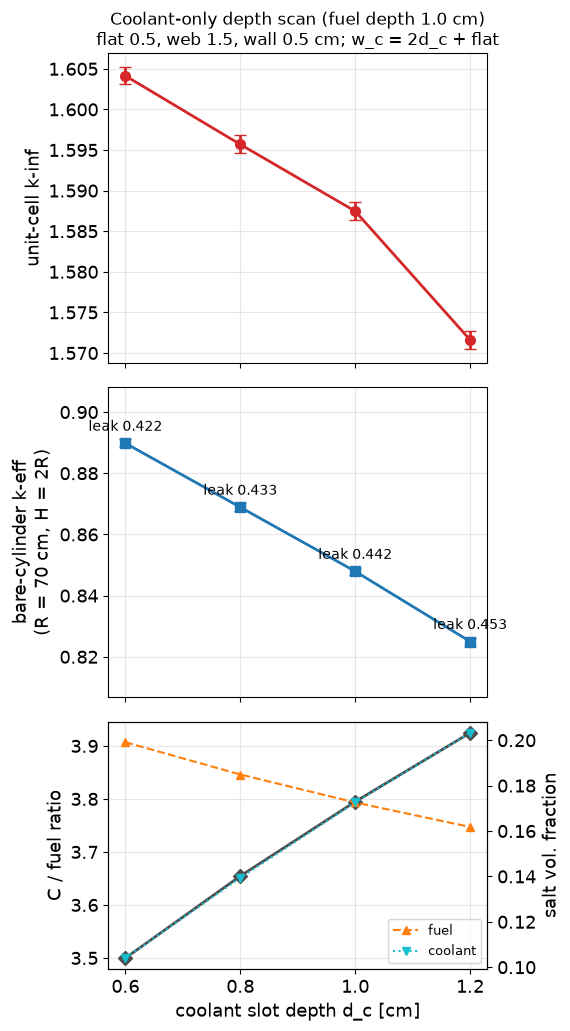

In [18]:
RUN_DEPTH_SCAN = False
SCAN_DEPTHS = [0.6, 0.8, 1.0, 1.2]
DS_FIXED = dict(flat_width=0.5, web_thickness=1.5, wall_thickness=0.5)
SCANS = {  # name: (csv, png, x column, geometry for depth x)
    "common":  ("depth_scan.csv", "depth_scan.png", "slot_depth", lambda x: dict(slot_depth=x, **DS_FIXED)),
    "coolant": ("coolant_depth_scan.csv", "coolant_depth_scan.png", "coolant_depth",
                lambda x: dict(slot_depth=1.0, coolant_depth=x, **DS_FIXED)),
}

def _run_k(m, cwd):
    sp_path = m.run(cwd=cwd, output=False, threads=THREADS)
    with openmc.StatePoint(sp_path) as sp:
        gt = sp.global_tallies
        names = [n.decode() if isinstance(n, bytes) else str(n) for n in gt["name"]]
        return sp.keff.nominal_value, sp.keff.std_dev, float(gt["mean"][names.index("leakage")])

def run_depth_scan(name):
    csv, _, xcol, geo_of = SCANS[name]
    rho_f = make_materials(temperature=TEMPERATURE_K, enrichment=ENRICHMENT)["fuel"].density
    rows = []
    for x_ in SCAN_DEPTHS:
        geo = geo_of(x_)
        am = analytic_metrics(core_radius=CORE_RADIUS, **geo, **GEOM_OPTS)
        base = os.path.join(WORK_DIR, "depth_scan" if name == "common" else "coolant_depth_scan", f"d{x_:.1f}")
        ki = _run_k(build_model(**geo, **GEOM_OPTS, mode="unit_cell", enrichment=ENRICHMENT, **RUN_OPTS), base + "_kinf")
        ke = _run_k(build_model(**geo, **GEOM_OPTS, mode="cylinder", core_radius=CORE_RADIUS, enrichment=ENRICHMENT, **RUN_OPTS), base + "_cyl")
        rows.append(dict(slot_depth=geo["slot_depth"], coolant_depth=am["coolant_depth"], **DS_FIXED, slot_width=am["slot_width"],
                         coolant_slot_width=am["coolant_slot_width"], kinf=ki[0], kinf_std=ki[1], keff=ke[0], keff_std=ke[1],
                         leakage_fraction=ke[2], fuel_vf=am["fuel_vf"], coolant_vf=am["coolant_vf"], graphite_vf=am["graphite_vf"],
                         graphite_to_fuel=am["graphite_to_fuel"], core_fuel_volume_l=am["core_fuel_volume_l"],
                         core_fuel_mass_kg=am["core_fuel_volume_l"] * rho_f))
    os.makedirs(os.path.join(WORK_DIR, "results"), exist_ok=True)
    pd.DataFrame(rows).to_csv(os.path.join(WORK_DIR, "results", csv), index=False)

def plot_depth_scan(ds, xcol, title, png):
    """phone-friendly: three stacked panels, large fonts"""
    with plt.rc_context({"font.size": 13}):
        fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(6, 10.5), sharex=True, gridspec_kw=dict(height_ratios=[1, 1, 0.8]))
        a1.errorbar(ds[xcol], ds.kinf, yerr=ds.kinf_std, fmt="o-", color="tab:red", capsize=4, lw=2, ms=7)
        a1.set_ylabel("unit-cell k-inf"); a1.grid(alpha=0.3); a1.set_title(title, fontsize=12)
        a2.errorbar(ds[xcol], ds.keff, yerr=ds.keff_std, fmt="s-", color="tab:blue", capsize=4, lw=2, ms=7)
        a2.set_ylabel(f"bare-cylinder k-eff\n(R = {CORE_RADIUS:.0f} cm, H = 2R)"); a2.grid(alpha=0.3)
        for x_, k_, L_ in zip(ds[xcol], ds.keff, ds.leakage_fraction):
            a2.annotate(f"leak {L_:.3f}", (x_, k_), xytext=(0, 9), textcoords="offset points", ha="center", fontsize=10)
        a2.margins(y=0.25)
        a3.plot(ds[xcol], ds.graphite_to_fuel, "D-", color="0.3", lw=2, ms=7)
        a3.set_ylabel("C / fuel ratio"); a3.grid(alpha=0.3)
        b_ = a3.twinx()
        b_.plot(ds[xcol], ds.fuel_vf, "^--", color="tab:orange", lw=1.5, ms=6, label="fuel")
        b_.plot(ds[xcol], ds.coolant_vf, "v:", color="tab:cyan", lw=1.5, ms=6, label="coolant")
        b_.set_ylabel("salt vol. fraction"); b_.legend(fontsize=9, loc="best")
        a3.set_xlabel(("slot depth d" if xcol == "slot_depth" else "coolant slot depth d_c") + " [cm]"); a3.set_xticks(ds[xcol])
        fig.tight_layout(); os.makedirs(os.path.dirname(png), exist_ok=True); fig.savefig(png, dpi=150); plt.show()

TITLES = {"common": "Slot depth scan (fuel = coolant slots)\nflat 0.5, web 1.5, wall 0.5 cm; w = 2d + flat",
          "coolant": "Coolant-only depth scan (fuel depth 1.0 cm)\nflat 0.5, web 1.5, wall 0.5 cm; w_c = 2d_c + flat"}
SHOW = ["slot_depth", "coolant_depth", "slot_width", "coolant_slot_width", "kinf", "kinf_std", "keff", "keff_std", "leakage_fraction",
        "fuel_vf", "coolant_vf", "graphite_vf", "graphite_to_fuel", "core_fuel_volume_l", "core_fuel_mass_kg"]
depth_scans = {}
for name, (csv, png, xcol, _) in SCANS.items():
    path = os.path.join(WORK_DIR, "results", csv)
    if RUN_DEPTH_SCAN and HAVE_XS:
        run_depth_scan(name)
    if not os.path.exists(path):
        print(f"[{name}] no results at {path} - run dev/depth_scan.py {name} or set RUN_DEPTH_SCAN = True"); continue
    ds = depth_scans[name] = pd.read_csv(path)
    print(f"\n{name} depth scan:"); display(ds[[c for c in SHOW if c in ds]].round(5))
    plot_depth_scan(ds, xcol, TITLES[name], os.path.join(WORK_DIR, "figures", png))

## Notes / next steps
* Raise `PARTICLES`/`BATCHES` (e.g. 20 000 × 150) and `N_SAMPLES` for real studies; each unit-cell run is independent → trivially parallel.
* Useful extra outputs to add per sample: fuel/coolant temperature coefficients (re-run at ±ΔT), conversion ratio (tally U-238 capture / U-235 absorption), spectrum.
* `mode="unit_cell"` gives the quick periodic k-inf model; `reflector_thickness` adds graphite around the cylinder.
* All slots are identical by design (Brian); the profile builder takes width/depth per call if that ever needs to change.